## Figure 7
## Supplementary Figure 16

## Helper codes: run below cells before any of the other cells. 

In [1]:
import pickle
from copy import deepcopy as dc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy import sparse
from scipy.stats import wilcoxon, kruskal, mannwhitneyu, sem, spearmanr, rankdata, pearsonr
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from itertools import combinations, product, permutations
import seaborn as sns
import math
from time import time
import networkx as nx
from ot.gromov import entropic_gromov_wasserstein, gromov_wasserstein, gwloss 
from statsmodels.stats.multitest import multipletests

from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split, KFold, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

from umap import UMAP

c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# loading

with open('SNN_adjmat.pickle', 'rb') as f:
    SNN_adjmat = pickle.load(f)

    list_j = SNN_adjmat['list_j'].copy()
    list_j_Q1 = SNN_adjmat['list_j_Q1'].copy()
    list_adjmat = SNN_adjmat['list_adjmat'].copy()
    list_adjmat_Q1 = SNN_adjmat['list_adjmat_Q1'].copy()

In [4]:
def compute_mean_var_trial(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1)
        trial_var = np.var(trial_rate, axis=1, ddof=1)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = pd.concat([trial_mean] * label_cnt_dict[trial_type], axis=1)
        list_trial_var[trial_ind] = pd.concat([trial_var] * label_cnt_dict[trial_type], axis=1)

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [5]:
def compute_mean_var_trial_collapse(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = trial_mean.copy()
        list_trial_var[trial_ind] = trial_var.copy()

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [6]:
# %%
# Function to compute cosine similarity
def cos_sim(x, y):
    # x and y are 1D vectors

    # Remove NaN
    x, y = np.array(x), np.array(y)
    bool_notnan = np.logical_and(~np.isnan(x), ~np.isnan(y))
    x, y = x[bool_notnan].copy(), y[bool_notnan].copy()

    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

In [7]:
def annotate_lineplot_significance(significant_values, axes, ax_ind, line_height_ratio, color):

    if len(significant_values) > 0:

        # Initialize start and end points of lines
        start = None
        lines = []
        dots = []

        # Loop through sorted significant_values to group them into lines or dots
        for i in range(len(significant_values) - 1):
            if start is None:
                start = significant_values[i]

            # Check if the next value is part of the same line
            if significant_values[i + 1] - significant_values[i] > 0.1 + 1e-9:  # Threshold for a gap; add pseudo-value to avoid floating point issue
                if start == significant_values[i]:
                    dots.append(start)  # Isolated point
                else:
                    lines.append((start, significant_values[i]))  # Line segment
                start = None

        # Check the last value
        if start is None:
            dots.append(significant_values[-1])
        else:
            lines.append((start, significant_values[-1]))

        # Plot lines and dots
        for line in lines:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)  # Draw a line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
                
        for dot in dots:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)  # Draw a very short line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)

In [8]:
def get_upper_whisker(data, whis=1.5):
    """Calculates the top of the upper whisker (ignoring hidden outliers)."""
    data = np.array(data)
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    upper_bound = q3 + whis * iqr
    valid_points = data[data <= upper_bound]
    
    return np.nanmax(valid_points) if len(valid_points) > 0 else np.nanmax(data)

def add_significance_bars(ax, comparisons, y_max_values, x_positions=None, p_values=None, 
                          gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, fontsize=10, ignore_ns=True):

    if p_values is None: p_values = ['*' for _ in comparisons]
    if x_positions is None: x_positions = np.arange(len(y_max_values))
    if ignore_ns:
        pval_thres = 0.05
    else:
        pval_thres = 1
    
    # Sort Comparisons: Distance first, then height
    def sort_key(item):
        (idx1, idx2), _ = item
        x_min, x_max = min(idx1, idx2), max(idx1, idx2)
        dist = x_max - x_min
        height = max(y_max_values[x_min : x_max + 1])
        return (dist, height)

    combined = list(zip(comparisons, p_values))
    combined.sort(key=sort_key)
    sorted_comparisons, sorted_p_values = zip(*combined)
    
    # Scale Factors
    y_min, y_max = np.nanmin(y_max_values), np.nanmax(y_max_values)
    y_range = y_max - y_min if y_max != y_min else 1.0

    # Get physical figure size in inches
    fig = ax.get_figure()
    fig_height_inch = fig.get_figheight()
    
    # Get axis height in fraction of figure (e.g., 0.8)
    bbox = ax.get_position()
    ax_height_inch = fig_height_inch * bbox.height

    # Get current Y-axis range (data units)
    y_min, y_max = ax.get_ylim()
    y_range_real = y_max - y_min

    # Conversion: (Points / 72 inch/pt) * (Data Range / Axis Height inches)
    text_height_data = (fontsize / 72) * (y_range_real / ax_height_inch)
    
    # Define gaps relative to the text size
    clearance = text_height_data * gap_below_line
    text_height = text_height_data
    
    # Initialize Interval Skyline
    # If we have N columns, we have N-1 gaps.
    n_columns = len(y_max_values)
    interval_skyline = [0] * (n_columns - 1)
    
    # Draw Bars
    for com_ind, ((idx1, idx2), pval) in enumerate(zip(sorted_comparisons, sorted_p_values)):
        if pval <= pval_thres:
            x1, x2 = min(idx1, idx2), max(idx1, idx2)
            
            # Check Data Height
            data_peak = np.nanmax(y_max_values[x1 : x2 + 1])
            
            # Check Interval Height
            if x1 < x2:
                interval_peak = np.nanmax(interval_skyline[x1:x2]) if interval_skyline[x1:x2] else 0
            else:
                interval_peak = 0
                
            # Determine drawing height
            # Must clear both the data and the previous bars below it
            y_line = np.nanmax([data_peak, interval_peak]) + clearance
            
            # if adjacent bars have same height, move up the second one
            if com_ind >= 1:
                idx1_prev, idx2_prev = sorted_comparisons[com_ind-1]
                x1_prev, x2_prev = min(idx1_prev, idx2_prev), max(idx1_prev, idx2_prev)
                pval_prev = sorted_p_values[com_ind-1]
                if x2 - x1 == 1 and x2_prev - x1_prev == 1 and x1 == x2_prev and pval_prev <= pval_thres:
                    y_line_prev = interval_skyline[x1_prev] - text_height
                    if np.isclose(y_line, y_line_prev):
                        y_line += clearance * bottomline_offset

            # Draw Line
            x_pos1, x_pos2 = x_positions[x1], x_positions[x2]
            line_x = [x_pos1, x_pos2]
            line_y = [y_line, y_line]
            ax.plot(line_x, line_y, lw=1.5, c='k')
        
            # Add Text
            text_y = y_line + (clearance * gap_below_text)
            if pval < 0.001:
                asterisk = '***'
            elif pval < 0.01:
                asterisk = '**'
            elif pval < 0.05:
                asterisk = '*'
            else:
                asterisk = f'p={pval:.2f}'
            ax.text((x_pos1 + x_pos2) * 0.5, text_y, asterisk, ha='center', va='bottom', color='k')
            
            # Update Interval Skyline
            new_height = y_line + text_height
            for k in range(x1, x2):
                interval_skyline[k] = new_height

    return ax

In [9]:
def heatmap_cbar(data, figsize_hm=(4, 4), figsize_all=(5, 4),
                 cmap="rocket", vmin=None, vmax=None, heatmap_kws=None, cbar_kws=None):
    """
    Make figsize=figsize_all where:
      - heatmap matches seaborn heatmap in figsize_hm with cbar=False
      - colorbar width + gap match seaborn heatmap in figsize_all with cbar=True
    """
    heatmap_kws = {} if heatmap_kws is None else dict(heatmap_kws)
    cbar_kws    = {} if cbar_kws is None else dict(cbar_kws)

    if vmin is None: vmin = np.nanmin(data)
    if vmax is None: vmax = np.nanmax(data)

    def bbox_in_inches(fig, ax):
        fig.canvas.draw()
        b = ax.get_position() # figure-fraction
        fw, fh = fig.get_size_inches()
        return (b.x0 * fw, b.y0 * fh, b.width * fw, b.height * fh)

    # Reference A: figsize_hm, cbar=False → heatmap axes box
    figA, axA = plt.subplots(figsize=figsize_hm)
    sns.heatmap(data, ax=axA, cbar=False, cmap=cmap, vmin=vmin, vmax=vmax, **heatmap_kws)
    hm_x0, hm_y0, hm_w, hm_h = bbox_in_inches(figA, axA)
    plt.close(figA)

    # Reference B: figsize_all, cbar=True → colorbar width + gap
    figB, axB = plt.subplots(figsize=figsize_all)
    hmB = sns.heatmap(data, ax=axB, cbar=True, cmap=cmap, vmin=vmin, vmax=vmax,
                      cbar_kws=cbar_kws, **heatmap_kws)
    caxB = hmB.figure.axes[-1]
    hmB_x0, hmB_y0, hmB_w, hmB_h = bbox_in_inches(figB, axB)
    cbB_x0, cbB_y0, cbB_w, cbB_h = bbox_in_inches(figB, caxB)
    gap = cbB_x0 - (hmB_x0 + hmB_w) # inches
    cbar_w = cbB_w # inches
    plt.close(figB)

    # Final: figsize_all with manual axes placement
    fig = plt.figure(figsize=figsize_all)
    fw, fh = fig.get_size_inches()

    ax_hm = fig.add_axes([hm_x0/fw, hm_y0/fh, hm_w/fw, hm_h/fh])

    cb_x0 = hm_x0 + hm_w + gap
    ax_cb = fig.add_axes([cb_x0/fw, hm_y0/fh, cbar_w/fw, hm_h/fh])

    sns.heatmap(data, ax=ax_hm, cbar=True, cbar_ax=ax_cb, cmap=cmap,
                vmin=vmin, vmax=vmax, cbar_kws=cbar_kws, **heatmap_kws)

    return fig, ax_hm, ax_cb

In [10]:
def compute_spkcnt_slope_comb(net_params=None, stim_params=None, sim_params=None, misc_params=None, across_stimuli=False, spkcnt=None, compute_slope=True):

    save_path = 'D:\\Users\\USER\\Shin Lab\\EI_cluster_network\\'
    save_name_sum = ''
    if net_params is not None:
        for key, value in net_params.items():
            if key != 'baseline_conn_prob':
                save_name_sum += '_' + key + str(value)    
            else:
                save_name_sum += '_' + 'p'
                for p in value.flatten():
                    save_name_sum += str(int(p*10))    
    if stim_params is not None: # if stim_dict was changed from default
        for key, value in stim_params.items():
            # if key in ['n_stim_clusters', 'n_stims', 'stim_amp']:
            # if key in ['n_stim_clusters', 'n_stims', 'n_trials', 'stim_amp']:
                save_name_sum += '_' + key + str(value)
    if sim_params is not None:
        for key, value in sim_params.items():
            save_name_sum += '_' + key + str(value)
    if misc_params is not None:
        for key, value in misc_params.items():
            save_name_sum += '_' + key + str(value)

    save_file_name = 'ei_clust_result' + save_name_sum + '.pickle'
    save_file_name = save_path + save_file_name
    with open(save_file_name, 'rb') as f:
        ei_clust_result = pickle.load(f)
    params_sim = dc(ei_clust_result['_params'])
    try:
        adjmat = dc(ei_clust_result['adjmat'])
    except:
        adjmat = None
    
    if spkcnt is None:
        # spike train
        spiketimes = ei_clust_result['spiketimes'].copy() # (2, num_tot_spikes) -> row 0 is spike times, row 1 is neuron ids
        N_E, N_I = params_sim['N_E'], params_sim['N_I']
        neu_inds_t = spiketimes[1].astype(int).copy()
        neu_inds = np.unique(neu_inds_t)
        spktrn0 = np.zeros((N_E+N_I, int(params_sim['simtime'] + 1)))
        for neu_ind in neu_inds:
            # if neu_ind % 1000 == 0:
            #     print(f'neu_ind {neu_ind}')
            spktrn0[neu_ind, spiketimes[0, neu_inds_t == neu_ind].astype(int)] = 1
        # print((spktrn0 > 0).sum() == spiketimes.shape[1]) # must be equal
        spktrn = spktrn0[:, 1:].copy() # exclude 0 ms

        # spike count mean-var
        n_clusters = net_params['n_clusters']
        n_stims = stim_params['n_stims']; n_trials = stim_params['n_trials']; dur_stim = stim_params['dur_stim']
        if stim_params.get('n_stim_clusters') is not None:
            n_stim_clusters = stim_params['n_stim_clusters']
            n_stims_temp = np.min([n_stims, math.comb(n_clusters, n_stim_clusters)])
        elif stim_params.get('n_stim_neurons') is not None:
            n_stim_neurons = stim_params['n_stim_neurons']
            n_stims_temp = n_stims

        # spktrn_3d = spktrn.reshape(N_E+N_I, -1, dur_stim) # n_neurons, n_trials, dur_stim
        spktrn_3d = spktrn[:, :int(n_stims_temp*n_trials*dur_stim)].reshape(N_E+N_I, -1, dur_stim) # to cover the case when simtime > total stimulation time
        spkcnt = spktrn_3d.sum(axis=2)
        # print(spkcnt.shape)
    
    if compute_slope:
        N_E, N_I = params_sim['N_E'], params_sim['N_I']
        n_clusters = net_params['n_clusters']
        n_stims = stim_params['n_stims']; n_trials = stim_params['n_trials']; dur_stim = stim_params['dur_stim']
        if stim_params.get('n_stim_clusters') is not None:
            n_stim_clusters = stim_params['n_stim_clusters']
            n_stims_temp = np.min([n_stims, math.comb(n_clusters, n_stim_clusters)])
        elif stim_params.get('n_stim_neurons') is not None:
            n_stim_neurons = stim_params['n_stim_neurons']
            n_stims_temp = n_stims
        stim_inds_trial = params_sim['stim_inds_trial'].copy()
        spkcnt = pd.DataFrame(spkcnt, columns=stim_inds_trial)
        stims_unique = np.unique(stim_inds_trial)
        cnt_mean, cnt_var = spkcnt.T.groupby(level=0).mean().T, spkcnt.T.groupby(level=0).var().T # (n_neurons, n_stims)
        list_slopes = np.full((2, n_stims), np.nan)
        for stim in stims_unique:
            temp_mean, temp_var = cnt_mean.loc[:, stim].copy(), cnt_var.loc[:, stim].copy()
            bool_mean_notzero = temp_mean > 0
            popt = np.polyfit(np.log10(temp_mean.loc[bool_mean_notzero]), np.log10(temp_var.loc[bool_mean_notzero]), 1)
            list_slopes[:, stim] = popt

            # fig, ax = plt.subplots(figsize=(4, 4))
            # ax.scatter(temp_mean, temp_var, marker='.', c='k')
            # ax.plot(temp_mean, temp_mean, c='gray', linestyle='--')
            # ax.annotate(f'Slope {popt[0]:.2f}', xy=(0.6, 0.05), xycoords='axes fraction', fontsize=16)
            
            # ax.set_xscale('log')
            # ax.set_yscale('log')
            # ax.set_xlabel('Mean (spike count)', fontsize=20)
            # ax.set_ylabel('Variance (spike count$^2$)', fontsize=20)
            # ax.tick_params(axis='both', labelsize=18)
            # # ax.set_xlim(0, 1.5)
            # # ax.set_ylim(0, 1.5)
            # plt.show()

        if across_stimuli:
            list_slopes_acrtt = np.full((2, N_E+N_I), np.nan)
            for neu_ind in range(N_E+N_I):
                temp_mean, temp_var = cnt_mean.loc[neu_ind].copy(), cnt_var.loc[neu_ind].copy()
                bool_mean_notzero = temp_mean > 0
                # print(bool_mean_notzero.sum())
                if np.any(bool_mean_notzero):
                    popt = np.polyfit(np.log10(temp_mean.loc[bool_mean_notzero]), np.log10(temp_var.loc[bool_mean_notzero]), 1)
                list_slopes_acrtt[:, neu_ind] = popt
            list_slopes = dc([list_slopes_acrtt, list_slopes])
    else:
        list_slopes = None

    return spkcnt, list_slopes, params_sim, adjmat

## Codes for figures

## Figure 7a right, 7b

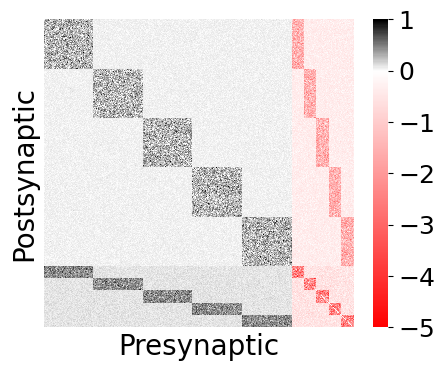

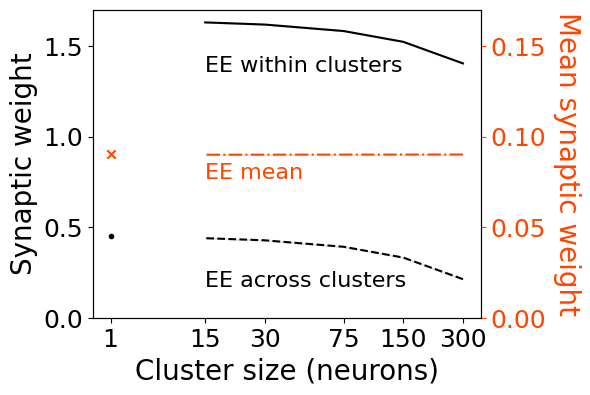

In [12]:
# synaptic weight matrix
n_sessions = 10
list_seed = np.linspace(1, 901, n_sessions, endpoint=True).astype(int)
list_Q = [5, 10, 20, 50, 100]
list_Q1 = [1]
n_stims = 5; n_trials = 200; dur_stim = 250; stim_amp = 0.1; stim_overlap = False; match_amp = True
n_neu_sampling = 10
N_E = 1200; N_I = 300
N = N_E + N_I

# list_j = np.empty((n_sessions, len(list_Q), 2, 2), dtype=object) # [[EE, EI], [IE, II]] # constant across sessions and Q, but calculatated repeatedly
# list_adjmat = np.full((n_sessions, len(list_Q), N, N), np.nan)
# for sess_ind, seed in enumerate(list_seed):
#     for ind, Q in enumerate(list_Q):
#         stcl = int(Q*0.2)
#         rep = 'm4'
#         # print(f'sess_ind={sess_ind}, Q={Q}')
#         net_params = dict(zip(['rep', 'n_clusters', 'conn_seed'], [rep, Q, seed])) # Caution on order! Order should reflect the name of loaded file
#         stim_params = dict(zip(['n_stim_clusters', 'n_stims', 'n_trials', 'dur_stim', 'stim_amp', 'stim_overlap', 'match_amp'],
#                                 [stcl, n_stims, n_trials, dur_stim, stim_amp, stim_overlap, match_amp]))
#         misc_params = {'adjmat': True}
#         _, _, params_sim, list_adjmat[sess_ind, ind] = \
#             compute_spkcnt_slope_comb(net_params=net_params, stim_params=stim_params, misc_params=misc_params, spkcnt=1, compute_slope=False)
#         list_j[sess_ind, ind] = [[params_sim['j_ee'], params_sim['j_ei']], [params_sim['j_ie'], params_sim['j_ii']]]

# list_j_Q1 = np.empty((n_sessions, len(list_Q1), 2, 2), dtype=object) # [[EE, EI], [IE, II]]
# list_adjmat_Q1 = np.full((n_sessions, len(list_Q1), N, N), np.nan)
# for sess_ind, seed in enumerate(list_seed):
#     for ind, Q in enumerate(list_Q1):
#         stneu = int(N_E*0.2)
#         # print(f'sess_ind={sess_ind}, Q={Q}')
#         net_params = dict(zip(['n_clusters', 'conn_seed'], [Q, seed])) # Caution on order! Order should reflect the name of loaded file
#         stim_params = dict(zip(['n_stim_neurons', 'n_stims', 'n_trials', 'dur_stim', 'stim_amp', 'stim_overlap', 'match_amp'],
#                                 [stneu, n_stims, n_trials, dur_stim, stim_amp, stim_overlap, match_amp]))
#         misc_params = {'adjmat': True}
#         _, _, params_sim, list_adjmat_Q1[sess_ind, ind] = \
#             compute_spkcnt_slope_comb(net_params=net_params, stim_params=stim_params, misc_params=misc_params, spkcnt=1, compute_slope=False)
#         list_j_Q1[sess_ind, ind] = [[params_sim['j_ee'], params_sim['j_ei']], [params_sim['j_ie'], params_sim['j_ii']]]

# 1. heatmap
zero_pos = 5 / 6 # zero is not at middle of cbar
colors = [(0.0, 'red'), (zero_pos, 'white'), (1.0, 'black')]
cmap = mcolors.LinearSegmentedColormap.from_list('asym_bwr', colors)

cbar = True
figsize = (4, 4)
adjmat_temp = np.mean(list_adjmat, axis=0)
vmin, vmax = -5, 1
for ind, Q in enumerate([list_Q[0]]):
    if cbar:
        fig, ax_hm, ax_cb = heatmap_cbar(adjmat_temp[ind].T,
                                         vmin=vmin, vmax=vmax,
                                         cmap=cmap,
                                        )
        ax_cb.tick_params(labelsize=18)

        # ax_hm.set_title(f'{Q} clusters', fontsize=20)
        ax_hm.set_xticks([])
        ax_hm.set_yticks([])
        ax_hm.set_xlabel('Presynaptic', fontsize=20)
        ax_hm.set_ylabel('Postsynaptic', fontsize=20)
        # ax_hm.xaxis.set_label_position('top')
        # ax_hm.xaxis.get_label().set_fontsize(20)
        # ax_hm.xaxis.get_label().set_text("Presynaptic")
    else:
        fig, ax_hm = plt.subplots(1, 1, figsize=figsize)
        ax_hm = sns.heatmap(adjmat_temp[ind],
                            vmin=vmin, vmax=vmax,
                            cbar=cbar)
# # plt.savefig('code_images\\svg\\SNN_w_heatmap.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\SNN_w_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. line plot
list_w_Q1 = np.full((n_sessions, len(list_Q1), 2), np.nan)
list_w_type_Q1 = np.full((n_sessions, len(list_Q1), 2, 2, 2), np.nan)
for sess_ind, seed in enumerate(list_seed):
    for ind, Q in enumerate(list_Q1):
        adjmat_temp = list_adjmat_Q1[sess_ind, ind]
        list_w_Q1[sess_ind, ind] = [np.sum(adjmat_temp), np.mean(adjmat_temp[adjmat_temp != 0])]

        is_E = np.zeros(N, dtype=bool)
        is_E[:N_E] = True
        is_I = ~is_E
        pre_E = is_E[:, None]
        post_E = is_E[None, :]
        pre_I = is_I[:, None]
        post_I = is_I[None, :]

        w_EE = adjmat_temp[pre_E & post_E]
        w_EI = adjmat_temp[pre_I & post_E]
        w_IE = adjmat_temp[pre_E & post_I]
        w_II = adjmat_temp[pre_I & post_I]
        
        list_w_type_Q1[sess_ind, ind, 0, 0] = [np.sum(w_EE), np.mean(w_EE[w_EE != 0])]
        list_w_type_Q1[sess_ind, ind, 0, 1] = [np.sum(w_EI), np.mean(w_EI[w_EI != 0])]
        list_w_type_Q1[sess_ind, ind, 1, 0] = [np.sum(w_IE), np.mean(w_IE[w_IE != 0])]
        list_w_type_Q1[sess_ind, ind, 1, 1] = [np.sum(w_II), np.mean(w_II[w_II != 0])]

list_w_within = np.full((n_sessions, len(list_Q), 2), np.nan)
list_w_across = np.full((n_sessions, len(list_Q), 2), np.nan)
list_w_within_type = np.full((n_sessions, len(list_Q), 2, 2, 2), np.nan)
list_w_across_type = np.full((n_sessions, len(list_Q), 2, 2, 2), np.nan)
for sess_ind, seed in enumerate(list_seed):
    for ind, Q in enumerate(list_Q):
        n_E_clust, n_I_clust = N_E // Q, N_I // Q
        ids_E = np.repeat(np.arange(Q), n_E_clust)
        ids_I = np.repeat(np.arange(Q), n_I_clust)
        all_ids = np.concatenate([ids_E, ids_I]) 
        bool_within_clust = (all_ids[:, None] == all_ids[None, :])
        bool_across_clust = ~bool_within_clust

        is_E = np.zeros(N, dtype=bool)
        is_E[:N_E] = True
        is_I = ~is_E
        pre_E = is_E[:, None]
        post_E = is_E[None, :]
        pre_I = is_I[:, None]
        post_I = is_I[None, :]

        adjmat_temp = list_adjmat[sess_ind, ind]
        w_within = adjmat_temp[bool_within_clust]
        w_across = adjmat_temp[bool_across_clust]
        w_EE_within = adjmat_temp[pre_E & post_E & bool_within_clust]
        w_EE_across = adjmat_temp[pre_E & post_E & bool_across_clust]
        w_EI_within = adjmat_temp[pre_I & post_E & bool_within_clust]
        w_EI_across = adjmat_temp[pre_I & post_E & bool_across_clust]
        w_IE_within = adjmat_temp[pre_E & post_I & bool_within_clust]
        w_IE_across = adjmat_temp[pre_E & post_I & bool_across_clust]
        w_II_within = adjmat_temp[pre_I & post_I & bool_within_clust]
        w_II_across = adjmat_temp[pre_I & post_I & bool_across_clust]
        
        list_w_within[sess_ind, ind] = [np.sum(w_within), np.mean(w_within[w_within != 0])]
        list_w_across[sess_ind, ind] = [np.sum(w_across), np.mean(w_across[w_across != 0])]
        list_w_within_type[sess_ind, ind, 0, 0] = [np.sum(w_EE_within), np.mean(w_EE_within[w_EE_within != 0])]
        list_w_across_type[sess_ind, ind, 0, 0] = [np.sum(w_EE_across), np.mean(w_EE_across[w_EE_across != 0])]
        list_w_within_type[sess_ind, ind, 0, 1] = [np.sum(w_EI_within), np.mean(w_EI_within[w_EI_within != 0])]
        list_w_across_type[sess_ind, ind, 0, 1] = [np.sum(w_EI_across), np.mean(w_EI_across[w_EI_across != 0])]
        list_w_within_type[sess_ind, ind, 1, 0] = [np.sum(w_IE_within), np.mean(w_IE_within[w_IE_within != 0])]
        list_w_across_type[sess_ind, ind, 1, 0] = [np.sum(w_IE_across), np.mean(w_IE_across[w_IE_across != 0])]
        list_w_within_type[sess_ind, ind, 1, 1] = [np.sum(w_II_within), np.mean(w_II_within[w_II_within != 0])]
        list_w_across_type[sess_ind, ind, 1, 1] = [np.sum(w_II_across), np.mean(w_II_across[w_II_across != 0])]

[[j_ee, j_ei], [j_ie, j_ii]] = list_j[0, 0] # constant across sessions and Q
list_en_size = [int(N/Q) for Q in list_Q]

# 2-1. weights for E/I within/across (exclude w=0 synapses)
fig, ax = plt.subplots(figsize=(5, 4))

sum_mean_ind = 1
list_num_within = 1
list_num_across = 1
list_w_EE_within_temp = list_w_within_type[:, :, 0, 0, sum_mean_ind] / list_num_within # convert sum to mean
list_w_EE_across_temp = list_w_across_type[:, :, 0, 0, sum_mean_ind] / list_num_across

list_w_type = [list_w_EE_within_temp, list_w_EE_across_temp]
list_colors = ['k', 'k']
list_ls = ['-', '--']
list_labels = ['EE within', 'EE across']
for i, list_w in enumerate(list_w_type):
    list_means_w = np.mean(list_w, axis=0)
    list_errs_w = sem(list_w, axis=0)
    color, ls, label = list_colors[i], list_ls[i], list_labels[i]
    ax.plot(list_en_size, list_means_w, color=color, linestyle=ls, label=label)
    ax.fill_between(list_en_size, list_means_w-list_errs_w,
                    list_means_w+list_errs_w, color=color, alpha=0.1)
    
# Q=1
sum_mean_ind = 1
list_num_w = 1
list_w_EE_temp = list_w_type_Q1[:, :, 0, 0, sum_mean_ind] / list_num_w # convert sum to mean
list_w_type = [list_w_EE_temp]
list_colors = ['k']
list_labels = ['EE (None)']
x_Q1 = 200 # number of clusters
x_Q1 = 5 # neurons per cluster
for i, list_w in enumerate(list_w_type):
    list_means_w = np.mean(list_w, axis=0)
    list_errs_w = sem(list_w, axis=0)
    color, label = list_colors[i], list_labels[i]
    ax.scatter([x_Q1], list_means_w, marker='.', color=color, label=label)
    ax.errorbar([x_Q1], list_means_w, yerr=list_errs_w, color=color, alpha=0.1)
ax.set_xscale('log', base=2)
# ax.set_xticks(list_Q + [x_Q1]) # number of clusters
# ax.set_xticklabels(list_Q + ['None'])
ax.set_xticks([x_Q1] + list_en_size) # neurons per cluster
ax.set_xticklabels([1] + list_en_size)
ax_xlim = ax.get_xlim()
ax.set_ylim(0, 1.7)

ax.set_xlabel('Number of clusters', fontsize=20)
ax.set_xlabel('Neurons per cluster', fontsize=20)
ax.set_xlabel('Cluster size (neurons)', fontsize=20)
ax.set_ylabel('Synaptic weight', fontsize=20)
ax.tick_params('both', labelsize=18)
# ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 12})

# ax.annotate(f'EE within clusters', xy=(0.25, 0.82), xycoords='axes fraction', fontsize=16, color='k') # number of clusters
# ax.annotate(f'EE across clusters', xy=(0.25, 0.12), xycoords='axes fraction', fontsize=16, color='k')
ax.annotate(f'EE within clusters', xy=(0.29, 0.8), xycoords='axes fraction', fontsize=16, color='k') # neurons per cluster
ax.annotate(f'EE across clusters', xy=(0.29, 0.1), xycoords='axes fraction', fontsize=16, color='k')

# # plt.savefig('code_images\\svg\\SNN_w_within_across_clust.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\SNN_w_within_across_clust.png', dpi=300, bbox_inches='tight')
# plt.show()

# 2-2. mean of weights for E/I
ax2 = ax.twinx() # share matplotlib figure, use right yaxis as second one
color_ax2 = 'orangered'

sum_mean_ind = 0
list_w_EE_within_temp = list_w_within_type[:, :, 0, 0, sum_mean_ind]
list_w_EE_across_temp = list_w_across_type[:, :, 0, 0, sum_mean_ind]
list_w_E = (list_w_EE_within_temp + list_w_EE_across_temp) / (N_E*N_E) # convert sum to mean (include w=0 synapses)
list_w_type = [list_w_E]
list_colors = [color_ax2]
list_ls = ['-.']
list_labels = ['EE mean']
for i, list_w in enumerate(list_w_type):
    list_means_w = np.mean(list_w, axis=0)
    list_errs_w = sem(list_w, axis=0)
    color, ls, label = list_colors[i], list_ls[i], list_labels[i]
    ax2.plot(list_en_size, list_means_w, color=color, linestyle=ls, label=label)
    ax2.fill_between(list_en_size, list_means_w-list_errs_w,
                    list_means_w+list_errs_w, color=color, alpha=0.1)

# Q=1
list_w_EE_temp = list_w_type_Q1[:, :, 0, 0, sum_mean_ind]
list_w_E = (list_w_EE_temp) / (N_E*N_E) # convert sum to mean (include w=0 synapses)
list_w_type = [list_w_E]
list_colors = [color_ax2]
list_mk = ['x']
list_labels = ['EE mean (None)']
x_Q1 = 200 # number of clusters
x_Q1 = 5 # neurons per cluster
for i, list_w in enumerate(list_w_type):
    list_means_w = np.mean(list_w, axis=0)
    list_errs_w = sem(list_w, axis=0)
    color, mk, label = list_colors[i], list_mk[i], list_labels[i]
    ax2.scatter([x_Q1], list_means_w, color=color, marker=mk, label=label)
    ax2.errorbar([x_Q1], list_means_w, yerr=list_errs_w, color=color, alpha=0.1)

# ax2.set_xscale('log')
# ax2.set_xticks(list_Q + [x_Q1])
# ax2.set_xticklabels(list_Q + ['None'])
ax.set_xlim(ax_xlim)
ax2.set_xlim(ax_xlim)
# ax2.invert_xaxis()
ax2.set_ylim(0, 0.17)

# ax2.set_xlabel('Number of clusters', fontsize=20)
ax2.set_ylabel('Mean synaptic weight', fontsize=20, rotation=270, labelpad=25, color=color_ax2)
ax2.tick_params('both', labelsize=18)
ax2.tick_params('y', colors=color_ax2)
# ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 12})
# ax.annotate(f'EE mean', xy=(0.5, 0.45), xycoords='axes fraction', fontsize=16, color=color_ax2) # number of clusters
ax.annotate(f'EE mean', xy=(0.29, 0.45), xycoords='axes fraction', fontsize=16, color=color_ax2) # neurons per cluster

# # plt.savefig('code_images\\svg\\SNN_w_within_across_mean.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\SNN_w_within_across_mean.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# save_file_name = 'SNN_adjmat.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_j', 'list_j_Q1', 'list_adjmat', 'list_adjmat_Q1'],
#                                     'list_j': list_j, 'list_j_Q1': list_j_Q1, 'list_adjmat': list_adjmat,
#                                     'list_adjmat_Q1': list_adjmat_Q1}, f)

## Figure 7c

In [14]:
# # Collect spike train, slope, RSM, corr within sess for each session
# similarity_type = 'cos_sim'

# n_sessions = 10
# list_Q = [5, 10, 20, 50, 100]
# # list_Q = [1]
# n_stims = 5
# n_neu_sampling = 10

# list_spkcnt_Qstcl = np.empty((n_sessions, len(list_Q)), dtype=object)
# # list_slopes_Qstcl = np.full((n_sessions, len(list_Q), n_stims), np.nan)
# list_slopes_Qstcl = np.full((n_sessions, len(list_Q), 2, n_stims), np.nan) # slope, intercept
# list_params_sim = np.empty((n_sessions, len(list_Q)), dtype=object)
# list_RSM_mean2 = np.full((n_sessions, len(list_Q), n_stims, n_stims), np.nan)
# list_RSM_neu1_all2 = np.full((n_sessions, len(list_Q), n_neu_sampling, n_stims, n_stims), np.nan)
# list_RSM_neu2_all2 = np.full((n_sessions, len(list_Q), n_neu_sampling, n_stims, n_stims), np.nan)
# list_corr_withinsess2 = np.full((n_sessions, len(list_Q), n_neu_sampling, 3), np.nan)
# for sess_ind in range(n_sessions):
#     file_name = 'RSA_across_within_sess' + str(sess_ind) + '.pickle'
#     file_name = 'RSA_across_within_sess_' + similarity_type + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         RSA_across_within_sess = pickle.load(f)
#         list_spkcnt_Qstcl[sess_ind] = RSA_across_within_sess['list_spkcnt_Qstcl'].copy()
#         list_slopes_Qstcl[sess_ind] = RSA_across_within_sess['list_slopes_Qstcl'].copy()
#         list_params_sim[sess_ind] = RSA_across_within_sess['list_params_sim'].copy()
#         list_RSM_mean2[sess_ind] = RSA_across_within_sess['list_RSM_mean'].copy()
#         list_RSM_neu1_all2[sess_ind] = RSA_across_within_sess['list_RSM_neu1_all'].copy()
#         list_RSM_neu2_all2[sess_ind] = RSA_across_within_sess['list_RSM_neu2_all'].copy()        
#         list_corr_withinsess2[sess_ind] = RSA_across_within_sess['list_corr_withinsess'].copy()

# save_file_name = 'RSA_across_within_sess_all44.pickle'
# save_file_name = 'RSA_across_within_sess_' + similarity_type + '_all6.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_spkcnt_Qstcl', 'list_slopes_Qstcl', 'list_params_sim', 'list_RSM_mean2', 'list_RSM_neu1_all2', 'list_RSM_neu2_all2', 'list_corr_withinsess2'],
#                     'list_spkcnt_Qstcl': list_spkcnt_Qstcl, 'list_slopes_Qstcl': list_slopes_Qstcl, 'list_params_sim': list_params_sim,
#                     'list_RSM_mean2': list_RSM_mean2, 'list_RSM_neu1_all2': list_RSM_neu1_all2, 'list_RSM_neu2_all2': list_RSM_neu2_all2, 'list_corr_withinsess2': list_corr_withinsess2}, f)

In [ ]:
# # Collect slope/intercept for each session
# n_sessions = 10
# list_Q = [5, 10, 20, 50, 100]
# list_Q1 = [1]
# n_stims = 5
# N_E = 1200; N_I = 300
# N = N_E + N_I

# list_slopes_Qstcl = np.full((n_sessions, len(list_Q), 2, n_stims), np.nan)
# list_slopes_acrneu2 = np.full((n_sessions, len(list_Q), 2, n_stims), np.nan)
# list_slopes_acrtt2 = np.full((n_sessions, len(list_Q), 2, N), np.nan)
# list_params_sim = np.empty((n_sessions, len(list_Q)), dtype=object)

# list_slopes_Qstcl_Q1 = np.full((n_sessions, len(list_Q1), 2, n_stims), np.nan)
# list_slopes_acrneu2_Q1 = np.full((n_sessions, len(list_Q1), 2, n_stims), np.nan)
# list_slopes_acrtt2_Q1 = np.full((n_sessions, len(list_Q1), 2, N), np.nan)
# list_params_sim_Q1 = np.empty((n_sessions, len(list_Q1)), dtype=object)
# for sess_ind in range(n_sessions):
#     file_name = 'slopes_SNN_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         slopes_SNN = pickle.load(f)
#         # list_slopes_Qstcl[sess_ind] = slopes_SNN['list_slopes_Qstcl'].copy()
#         list_slopes_acrneu2[sess_ind] = slopes_SNN['list_slopes_acrneu'].copy()
#         list_slopes_acrtt2[sess_ind] = slopes_SNN['list_slopes_acrtt'].copy()
#         list_params_sim[sess_ind] = slopes_SNN['list_params_sim'].copy()

#         # list_slopes_Qstcl_Q1[sess_ind] = slopes_SNN['list_slopes_Qstcl_Q1'].copy()
#         list_slopes_acrneu2_Q1[sess_ind] = slopes_SNN['list_slopes_acrneu_Q1'].copy()
#         list_slopes_acrtt2_Q1[sess_ind] = slopes_SNN['list_slopes_acrtt_Q1'].copy()
#         list_params_sim_Q1[sess_ind] = slopes_SNN['list_params_sim_Q1'].copy()

# save_file_name = 'slopes_SNN_all2.pickle'
# with open(save_file_name, 'wb') as f:
#     # pickle.dump({'tree_variables': ['list_slopes_Qstcl', 'list_slopes_Qstcl_Q1', 'list_params_sim', 'list_params_sim_Q1'],
#     #                 'list_slopes_Qstcl': list_slopes_Qstcl, 'list_slopes_Qstcl_Q1': list_slopes_Qstcl_Q1,
#     #                 'list_params_sim': list_params_sim, 'list_params_sim_Q1': list_params_sim_Q1}, f)
#     pickle.dump({'tree_variables': ['list_slopes_acrneu2', 'list_slopes_acrtt2', 'list_slopes_acrneu2_Q1', 'list_slopes_acrtt2_Q1', 'list_params_sim', 'list_params_sim_Q1'],
#                     'list_slopes_acrneu2': list_slopes_acrneu2, 'list_slopes_acrtt2': list_slopes_acrtt2, 'list_slopes_acrneu2_Q1': list_slopes_acrneu2_Q1, 'list_slopes_acrtt2_Q1': list_slopes_acrtt2_Q1,
#                     'list_params_sim': list_params_sim, 'list_params_sim_Q1': list_params_sim_Q1}, f)

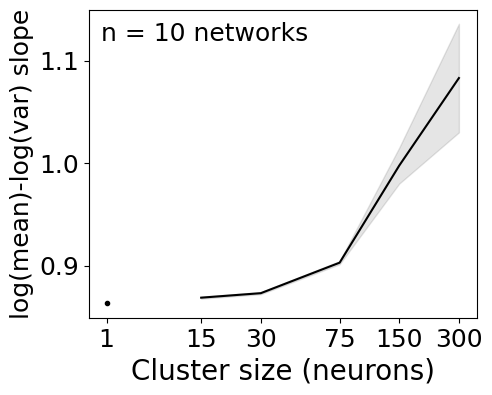

In [17]:
# slope across Q

similarity_type = 'cos_sim'

save_file_name = 'RSA_across_within_sess_all27.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_slopes_Qstcl = RSA_across_within_sess_all['list_slopes_Qstcl'].copy()
    list_params_sim = RSA_across_within_sess_all['list_params_sim'].copy()
similarity_type = 'cos_sim'
save_file_name = 'RSA_across_within_sess_' + similarity_type + '_all4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, within sess RSM, Q=1
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_slopes_Qstcl_Q1 = RSA_across_within_sess_all['list_slopes_Qstcl'].copy()

list_Q = [5, 10, 20, 50, 100, 300]
list_Q = list_Q[:-1] # exclude Q = 300
N_E = 1200; N_I = 300
N = N_E + N_I
list_en_size = [int(N/Q) for Q in list_Q]
list_slopes_Qstcl = list_slopes_Qstcl[:, :-1] # exclude Q = 300
n_sessions = list_slopes_Qstcl.shape[0]

fig, ax = plt.subplots(figsize=(5, 4))
mean_slope = np.nanmean(list_slopes_Qstcl, axis=(0, 2))
err_slope = sem(np.nanmean(list_slopes_Qstcl, axis=2), axis=0, nan_policy='omit')
ax.plot(list_en_size, mean_slope, c='k')
ax.fill_between(list_en_size, mean_slope-err_slope, mean_slope+err_slope, color='k', alpha=0.1)

# Q=1
mean_slope = np.nanmean(list_slopes_Qstcl_Q1, axis=(0, 2))
err_slope = sem(np.nanmean(list_slopes_Qstcl_Q1, axis=2), axis=0, nan_policy='omit')
x_Q1 = 200 # right side of line; number of clusters
x_Q1 = 5 # neurons per cluster
ax.scatter([x_Q1], mean_slope, marker='.', c='k')
ax.errorbar([x_Q1], mean_slope, yerr=err_slope, color='k', alpha=0.1)

ax.set_xlabel(f'Number of clusters', fontsize=20)
ax.set_xlabel(f'Neurons per cluster', fontsize=20)
ax.set_xlabel('Cluster size (neurons)', fontsize=20)
ax.set_ylabel('log(mean)-log(var) slope', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.set_xscale('log', base=2)
# ax.set_xticks([5, 50, 100, 300])
# ax.set_xticks(list_Q + [x_Q1])
# ax.set_xticklabels(list_Q + ['None'])
ax.set_xticks([x_Q1] + list_en_size)
ax.set_xticklabels([1] + list_en_size)
# ax.set_yticks(np.arange(0.8, 1.41, 0.2))
ax.set_yticks(np.arange(0.9, 1.11, 0.1))
# ax.annotate(f'n = {n_sessions} networks', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k') # number of clusters
ax.annotate(f'n = {n_sessions} networks', xy=(0.03, 0.9), xycoords='axes fraction', fontsize=18, color='k') # neurons per cluster

# plt.savefig('code_images\\svg\\SNN_slope_Q.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\SNN_slope_Q.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 7d

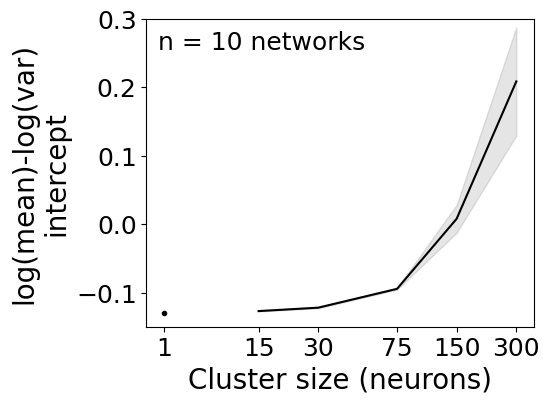

In [ ]:
# intercept across Q
save_file_name = 'slopes_SNN_all.pickle' # save27 + cos_sim save4
save_file_name = 'slopes_SNN_all2.pickle' # same as save1 for across neurons, include across stimuli
with open(save_file_name, 'rb') as f:
    slopes_SNN_all = pickle.load(f)
    # list_slopes_Qstcl = slopes_SNN_all['list_slopes_Qstcl'].copy()
    # list_slopes_Qstcl_Q1 = slopes_SNN_all['list_slopes_Qstcl_Q1'].copy()
    list_slopes_acrneu2 = slopes_SNN_all['list_slopes_acrneu2'].copy()
    list_slopes_acrtt2 = slopes_SNN_all['list_slopes_acrtt2'].copy()
    list_slopes_acrneu2_Q1 = slopes_SNN_all['list_slopes_acrneu2_Q1'].copy()
    list_slopes_acrtt2_Q1 = slopes_SNN_all['list_slopes_acrtt2_Q1'].copy()

si_ind = 1 # slope (0) or intercept (1)
list_Q = [5, 10, 20, 50, 100]
N_E = 1200; N_I = 300
N = N_E + N_I
list_en_size = [int(N/Q) for Q in list_Q]
fig, ax = plt.subplots(figsize=(5, 4))
mean_slope = np.nanmean(list_slopes_acrneu2[:, :, si_ind], axis=(0, 2))
err_slope = sem(np.nanmean(list_slopes_acrneu2[:, :, si_ind], axis=2), axis=0, nan_policy='omit')
ax.plot(list_en_size, mean_slope, c='k')
ax.fill_between(list_en_size, mean_slope-err_slope, mean_slope+err_slope, color='k', alpha=0.1)

# Q=1
mean_slope = np.nanmean(list_slopes_acrneu2_Q1[:, :, si_ind], axis=(0, 2))
err_slope = sem(np.nanmean(list_slopes_acrneu2_Q1[:, :, si_ind], axis=2), axis=0, nan_policy='omit')
x_Q1 = 200 # right side of line; number of clusters
x_Q1 = 5 # neurons per cluster
ax.scatter([x_Q1], mean_slope, marker='.', c='k')
ax.errorbar([x_Q1], mean_slope, yerr=err_slope, color='k', alpha=0.1)

ax.set_xlabel(f'Number of clusters', fontsize=20)
ax.set_xlabel(f'Neurons per cluster', fontsize=20)
ax.set_xlabel('Cluster size (neurons)', fontsize=20)
ax.set_ylabel('log(mean)-log(var)\nintercept', fontsize=20)
ax.tick_params(axis='both', labelsize=18)
ax.set_xscale('log', base=2)
# ax.set_xticks(list_Q + [x_Q1])
# ax.set_xticklabels(list_Q + ['None'])
ax.set_xticks([x_Q1] + list_en_size)
ax.set_xticklabels([1] + list_en_size)
ax.set_ylim(-0.15, 0.3)
# ax.set_yticks(np.arange(0.8, 1.21, 0.1))
# ax.annotate(f'n = {n_sessions} networks', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k') # number of clusters
ax.annotate(f'n = {n_sessions} networks', xy=(0.03, 0.9), xycoords='axes fraction', fontsize=18, color='k') # neurons per cluster

# plt.savefig('code_images\\svg\\SNN_intcpt_Q.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\SNN_intcpt_Q.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 7e

In [20]:
# # Collect effective dimensionality for each session
# n_sessions = 10
# list_Q = [5, 10, 20, 50, 100]
# # list_Q = [1]
# n_stims = 5
# n_trial_sampling = 100

# list_spkcnt_Qstcl = np.empty((n_sessions, len(list_Q)), dtype=object)
# list_slopes_Qstcl = np.full((n_sessions, len(list_Q), 2, n_stims), np.nan) # slope, intercept
# list_params_sim = np.empty((n_sessions, len(list_Q)), dtype=object)
# list_dim2 = np.zeros((n_sessions, len(list_Q), n_stims))
# list_dim_global2 = np.zeros((n_sessions, len(list_Q), 2))
# list_dim_sam2 = np.zeros((n_sessions, len(list_Q), n_trial_sampling))
# for sess_ind in range(n_sessions):
#     file_name = 'eff_dim_DC_SNN_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         eff_dim_DC_SNN = pickle.load(f)
#         list_spkcnt_Qstcl[sess_ind] = eff_dim_DC_SNN['list_spkcnt_Qstcl'].copy()
#         list_slopes_Qstcl[sess_ind] = eff_dim_DC_SNN['list_slopes_Qstcl'].copy()
#         list_params_sim[sess_ind] = eff_dim_DC_SNN['list_params_sim'].copy()
#         list_dim2[sess_ind] = eff_dim_DC_SNN['list_dim'].copy()
#         list_dim_global2[sess_ind] = eff_dim_DC_SNN['list_dim_global'].copy()
#         list_dim_sam2[sess_ind] = eff_dim_DC_SNN['list_dim_sam'].copy()

# save_file_name = 'eff_dim_DC_SNN4.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_spkcnt_Qstcl', 'list_slopes_Qstcl', 'list_params_sim', 'list_dim2', 'list_dim_global2', 'list_dim_sam2'],
#                 'list_spkcnt_Qstcl': list_spkcnt_Qstcl, 'list_slopes_Qstcl': list_slopes_Qstcl, 'list_params_sim': list_params_sim,
#                 'list_dim2': list_dim2, 'list_dim_global2': list_dim_global2, 'list_dim_sam2': list_dim_sam2}, f)

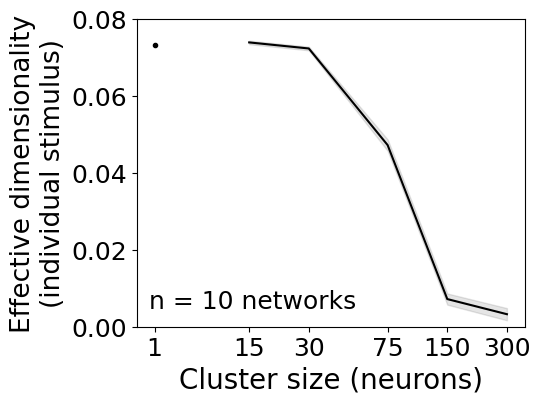

In [22]:
# Effective dimensionality (line plot)

save_file_name = 'eff_dim_DC_SNN3.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control (cf. save27), math corrected
with open(save_file_name, 'rb') as f:
    eff_dim_DC_SNN = pickle.load(f)
    list_spkcnt_Qstcl = eff_dim_DC_SNN['list_spkcnt_Qstcl'].copy()
    list_dim2 = eff_dim_DC_SNN['list_dim2'].copy()
    list_dim_global2 = eff_dim_DC_SNN['list_dim_global2'].copy()
    list_dim_sam2 = eff_dim_DC_SNN['list_dim_sam2'].copy()
save_file_name = 'eff_dim_DC_SNN4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, Q=1, math corrected
with open(save_file_name, 'rb') as f:
    eff_dim_DC_SNN = pickle.load(f)
    list_dim2_Q1 = eff_dim_DC_SNN['list_dim2'].copy()
    list_dim_global2_Q1 = eff_dim_DC_SNN['list_dim_global2'].copy()
    list_dim_sam2_Q1 = eff_dim_DC_SNN['list_dim_sam2'].copy()
list_dim2_all = np.concatenate([list_dim2_Q1, list_dim2], axis=1)
list_dim_global2_all = np.concatenate([list_dim_global2_Q1, list_dim_global2], axis=1)
list_dim_sam2_all = np.concatenate([list_dim_sam2_Q1, list_dim_sam2], axis=1)

n_sessions = list_spkcnt_Qstcl.shape[0]
list_seed = np.linspace(1, 901, n_sessions, endpoint=True).astype(int)
list_Q = [5, 10, 20, 50, 100]
list_Q1 = [1]
list_Q_all = list_Q1 + list_Q
n_stims = 5; n_trials = 200; dur_stim = 250; stim_amp = 0.1; stim_overlap = False; match_amp = True
N_E = 1200
list_en_size = [int(N/Q) for Q in list_Q]

# line plot
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

x = list_Q.copy()
x = list_en_size
sort_ind = np.arange(len(x))
list_means_dim = np.mean(list_dim2, axis=(0, 2))[sort_ind]
list_errs_dim = sem(np.mean(list_dim2, axis=2), axis=0)[sort_ind]

axes[0].plot(x, list_means_dim, color='k')
axes[0].fill_between(x, list_means_dim-list_errs_dim, \
                     list_means_dim+list_errs_dim, color='k', alpha=0.1)

# Q1
list_means_dim = np.mean(list_dim2_Q1, axis=(0, 2))
list_errs_dim = sem(np.mean(list_dim2_Q1, axis=2), axis=0)

x_Q1 = 200 # number of clusters
x_Q1 = 5 # neurons per cluster
axes[0].scatter(x_Q1, list_means_dim, marker='.', color='k')
axes[0].errorbar(x_Q1, list_means_dim,
yerr=list_errs_dim, color='k', alpha=0.1)

# significance
axes[0].set_ylim(0, 0.08)
# annotate_lineplot_significance(list_sig_slopes_dim, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')
# axes[0].set_yticks(np.arange(0.2, 0.42, 0.1))
# axes[0].set_yticks(np.arange(0.2, 0.52, 0.1)) # with shuffled

axes[0].set_xlabel('Number of clusters', fontsize=20)
axes[0].set_xlabel('Neurons per cluster', fontsize=20)
axes[0].set_xlabel('Cluster size (neurons)', fontsize=20)
# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=18)

axes[0].set_xscale('log', base=2)
# axes[0].set_xticks(list_Q + [x_Q1]) # number of clusters
# axes[0].set_xticklabels(list_Q + ['None'])
axes[0].set_xticks([x_Q1] + list_en_size) # neurons per cluster
axes[0].set_xticklabels([1] + list_en_size)
# axes[0].set_xlim(0.8, 1.3)
# axes[0].set_xticks(np.arange(0.8, 1.3, 0.2))

# axes[0].annotate(f'n = {list_dim2.shape[0]} networks', xy=(0.43, 0.06), xycoords='axes fraction', fontsize=18, color='k') # number of clusters
axes[0].annotate(f'n = {list_dim2.shape[0]} networks', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k') # neurons per cluster

# plt.savefig('code_images\\svg\\SNN_effdim.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\SNN_effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 7f

sess_ind = 6
Q = 1, slope = 0.87
stimulus [2 0 1 4 3] visualized


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


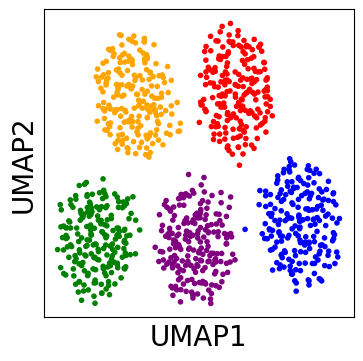

Q = 5, slope = 1.25
stimulus [2 0 1 4 3] visualized


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


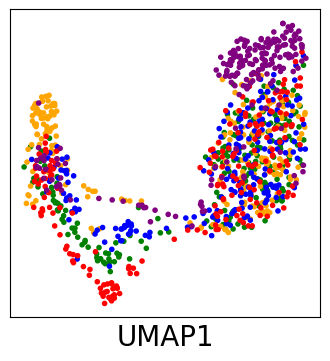

Q = 10, slope = 0.98
stimulus [2 0 1 4 3] visualized


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


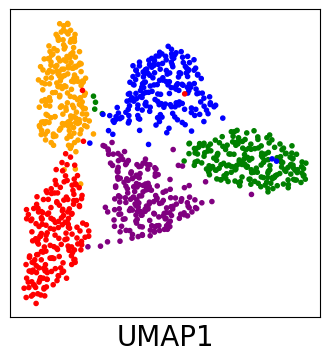

Q = 20, slope = 0.90
stimulus [2 0 1 4 3] visualized


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


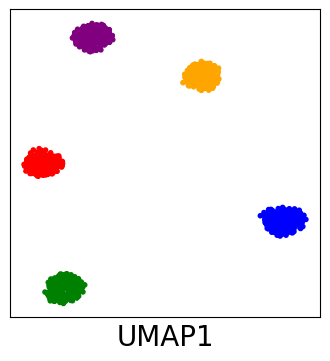

In [35]:
# Visualization (umap)

similarity_type = 'cos_sim'

save_file_name = 'RSA_across_within_sess_all27.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_spkcnt_Qstcl = RSA_across_within_sess_all['list_spkcnt_Qstcl'].copy()
    list_slopes_Qstcl = RSA_across_within_sess_all['list_slopes_Qstcl'].copy()
    list_params_sim = RSA_across_within_sess_all['list_params_sim'].copy()
save_file_name = 'RSA_across_within_sess_' + similarity_type + '_all4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, within sess RSM, Q=1
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_spkcnt_Qstcl_Q1 = RSA_across_within_sess_all['list_spkcnt_Qstcl'].copy()
    list_slopes_Qstcl_Q1 = RSA_across_within_sess_all['list_slopes_Qstcl'].copy()
list_spkcnt_Qstcl = np.concatenate([list_spkcnt_Qstcl_Q1, list_spkcnt_Qstcl], axis=1)
list_slopes_Qstcl = np.concatenate([list_slopes_Qstcl_Q1, list_slopes_Qstcl], axis=1)

n_sessions = list_spkcnt_Qstcl.shape[0]
list_Q = [5, 10, 20, 50, 100]
list_Q = [1, 5, 10, 20, 50, 100]
n_stims = 5; n_trials = 200; dur_stim = 250; stim_amp = 0.15

# visualization
sess_ind = np.random.choice(range(n_sessions), 1)[0]
sess_ind = 6
print(f'sess_ind = {sess_ind}')
for ind, Q in enumerate(list_Q):
    if Q in [1, 5, 10, 20]:
        print(f'Q = {Q}, slope = {np.nanmean(list_slopes_Qstcl[sess_ind, ind]):.2f}')
        rng = np.random.default_rng(10)

        spkcnt = list_spkcnt_Qstcl[sess_ind, ind].copy()
        spkcnt_sorted = spkcnt.sort_index(axis=1)
        all_stm_unique, all_stm_counts = np.unique(spkcnt_sorted.columns, return_counts=True)
        n_trials = all_stm_counts[0]
        
        n_stim_vis = np.min([5, len(all_stm_unique)])
        tt_trio = rng.choice(all_stm_unique, n_stim_vis, replace=False)
        print(f'stimulus {tt_trio} visualized')

        # umap
        n_components = 2 # target number of dimensions
        n_neighbors = spkcnt.shape[1] // 25 # number of neighbors
        min_dist = 0.8
        random_state = 0
        umap = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=min_dist, random_state=random_state)
        spkcnt_umap = pd.DataFrame(umap.fit_transform(spkcnt.T).T, columns=spkcnt.columns)
        list_colors = np.array(['green', 'orange', 'blue', 'red', 'purple'])[:n_stim_vis]
        color = np.repeat(list_colors, n_trials)

        fig, ax = plt.subplots(figsize=(4, 4))
        ax.scatter(spkcnt_umap.loc[0, tt_trio], spkcnt_umap.loc[1, tt_trio], marker='.', color=color)
        ax.set_xlabel(f'UMAP1', fontsize=20)
        if Q == 1:
            ax.set_ylabel(f'UMAP2', fontsize=20)
        ax.tick_params(axis='both', labelsize=18)
        ax.set_xticks([])
        ax.set_yticks([])

        # plt.savefig(f'code_images\\SNN_umap_Q{Q}.svg', bbox_inches='tight')
        # plt.savefig(f'code_images\\SNN_umap_Q{Q}.png', dpi=300, bbox_inches='tight')
        plt.show()

## Supplementary Figure 16a

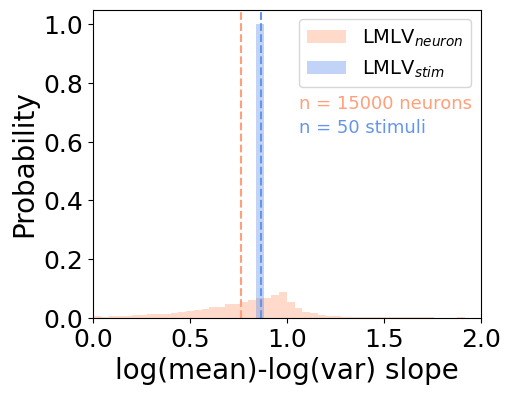

Neurons mean 0.7645310231563031, std 0.3814993937779652, SEM 0.003114929506457088
Stimuli mean 0.8638892654985051, std 0.004487867430700991, SEM 0.0006346802986629838


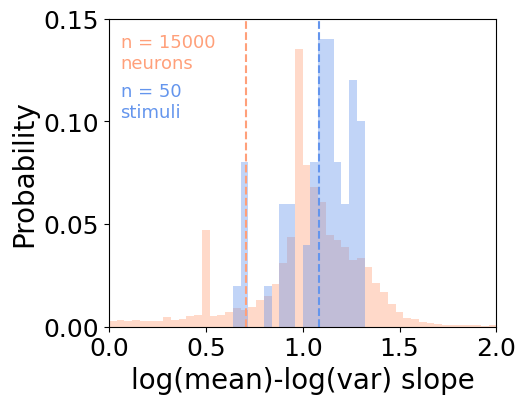

Neurons mean 0.7054894646176233, std 1.3110871111767006, SEM 0.010704981435741855
Stimuli mean 1.0829998817603386, std 0.17534087919256405, SEM 0.02479694493925465


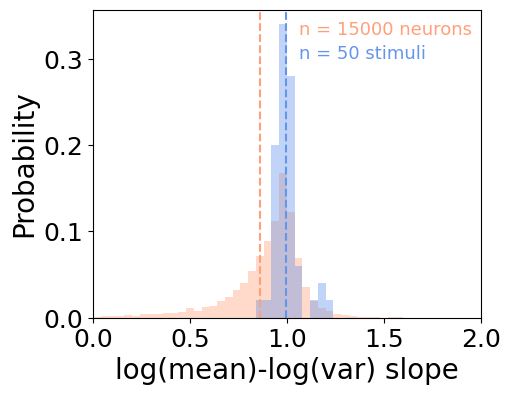

Neurons mean 0.8636211803818739, std 0.3126143349888351, SEM 0.0025524853566737866
Stimuli mean 0.9976580076937069, std 0.06697487495318498, SEM 0.00947167764970363


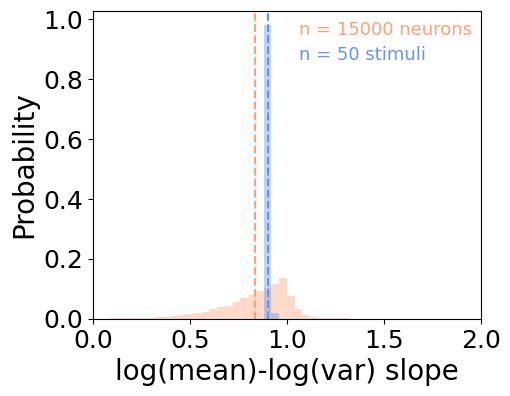

Neurons mean 0.8361858229962186, std 0.18711633725857693, SEM 0.0015277984960734732
Stimuli mean 0.9028634716841459, std 0.007570650381338771, SEM 0.0010706516445274333


In [26]:
# slope histogram across stimuli vs. across neurons

save_file_name = 'slopes_SNN_all2.pickle' # same as save1 for across neurons, include across stimuli
with open(save_file_name, 'rb') as f:
    slopes_SNN_all = pickle.load(f)
    # list_slopes_Qstcl = slopes_SNN_all['list_slopes_Qstcl'].copy()
    # list_slopes_Qstcl_Q1 = slopes_SNN_all['list_slopes_Qstcl_Q1'].copy()
    list_slopes_acrneu2 = slopes_SNN_all['list_slopes_acrneu2'].copy()
    list_slopes_acrtt2 = slopes_SNN_all['list_slopes_acrtt2'].copy()
    list_slopes_acrneu2_Q1 = slopes_SNN_all['list_slopes_acrneu2_Q1'].copy()
    list_slopes_acrtt2_Q1 = slopes_SNN_all['list_slopes_acrtt2_Q1'].copy()
list_Q = [5, 10, 20, 50, 100]
list_Q1 = [1]
list_Q_all = list_Q1 + list_Q
list_slopes_acrtt2_all = np.concatenate([list_slopes_acrtt2_Q1, list_slopes_acrtt2], axis=1)
list_slopes_acrneu2_all = np.concatenate([list_slopes_acrneu2_Q1, list_slopes_acrneu2], axis=1)

# pool across sessions
for ind, Q in enumerate(list_Q_all):
    if Q in [1, 5, 10, 20]:
        list_slopes_acrtt2_flattened = list_slopes_acrtt2_all[:, ind, 0].flatten()
        list_slopes_acrneu2_flattened = list_slopes_acrneu2_all[:, ind, 0].flatten()
        
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        lower_bound, upper_bound = 0, 2
        n_bins = 50

        weights = np.ones_like(list_slopes_acrtt2_flattened)
        weights = np.ones_like(list_slopes_acrtt2_flattened) / len(list_slopes_acrtt2_flattened)
        ax.hist(list_slopes_acrtt2_flattened, range=(lower_bound, upper_bound), bins=n_bins, weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$')
        ax.axvline(np.nanmean(list_slopes_acrtt2_flattened), color='lightsalmon', linestyle='--')

        weights = np.ones_like(list_slopes_acrneu2_flattened)
        weights = np.ones_like(list_slopes_acrneu2_flattened) / len(list_slopes_acrneu2_flattened)
        ax.hist(list_slopes_acrneu2_flattened, range=(lower_bound, upper_bound), bins=n_bins, weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$')
        ax.axvline(np.nanmean(list_slopes_acrneu2_flattened), color='cornflowerblue', linestyle='--')
        
        # weights = np.ones_like(list_slopes_acrneu_noclust2_flattened)
        # weights = np.ones_like(list_slopes_acrneu_noclust2_flattened) / len(list_slopes_acrneu_noclust2_flattened)
        # ax.hist(list_slopes_acrneu_noclust2_flattened, range=(lower_bound, upper_bound), bins=n_bins, weights=weights, color='darkorange', alpha=0.4, label='no cluster')
        
        # ax.set_title(f'{Q} clusters', fontsize=20)
        ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
        # if Q == 1:
        ax.set_ylabel('Number of stimuli', fontsize=20)
        ax.set_ylabel('Probability', fontsize=20)
        ax.tick_params('both', labelsize=18)
        ax.set_xlim(0, 2)

        if Q == 5:
            ax.set_yticks(np.arange(0, 0.16, 0.05))
        if Q == 1:
            ax.legend(loc='upper right', prop={'size': 14})
            # ax.legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})
        x_text = 0.03 if Q == 5 else 0.53
        if Q == 1:
            y_text = 0.68
        elif Q == 5:
            y_text = 0.84
        else:
            y_text = 0.92
        if Q == 5:
            ax.annotate(f'n = {list_slopes_acrtt2_flattened.shape[0]}\nneurons', xy=(x_text, y_text), xycoords='axes fraction', fontsize=13, color='lightsalmon')
            ax.annotate(f'n = {list_slopes_acrneu2_flattened.shape[0]}\nstimuli', xy=(x_text, y_text-0.16), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
        else:
            ax.annotate(f'n = {list_slopes_acrtt2_flattened.shape[0]} neurons', xy=(x_text, y_text), xycoords='axes fraction', fontsize=13, color='lightsalmon')
            ax.annotate(f'n = {list_slopes_acrneu2_flattened.shape[0]} stimuli', xy=(x_text, y_text-0.08), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

        # plt.savefig(f'code_images\\svg\\SNN_slope_histogram_2cond_Q{Q}.svg', bbox_inches='tight')
        # plt.savefig(f'code_images\\png\\SNN_slope_histogram_2cond_Q{Q}.png', dpi=300, bbox_inches='tight')
        plt.show()

        print(f'Neurons mean {np.mean(list_slopes_acrtt2_flattened)}, std {np.std(list_slopes_acrtt2_flattened, ddof=1)}, SEM {sem(list_slopes_acrtt2_flattened)}')
        print(f'Stimuli mean {np.mean(list_slopes_acrneu2_flattened)}, std {np.std(list_slopes_acrneu2_flattened, ddof=1)}, SEM {sem(list_slopes_acrneu2_flattened)}')

## Supplementary Figure 16b

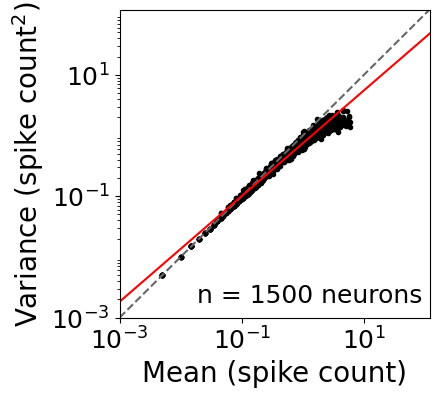

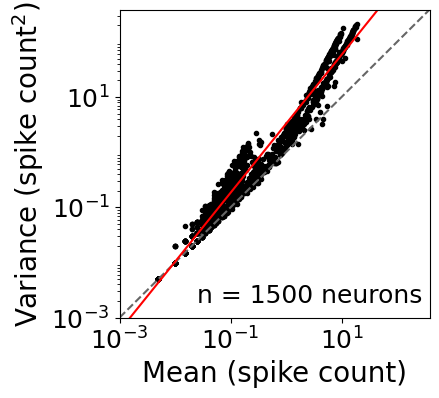

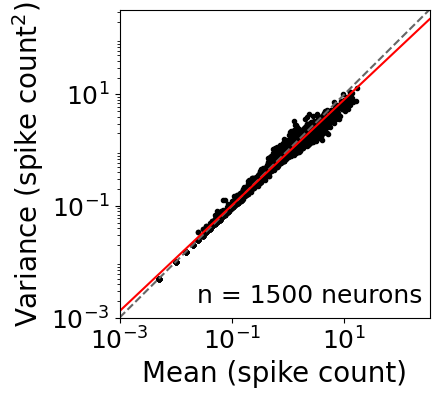

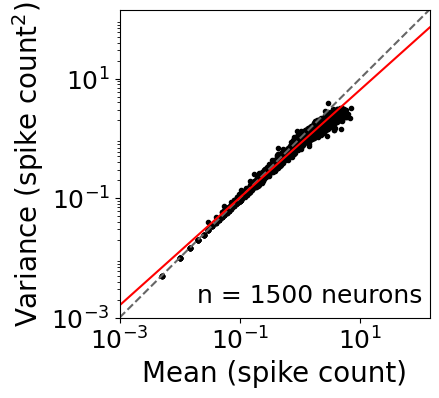

In [27]:
# mean-var plot

save_file_name = 'RSA_across_within_sess_all27.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_spkcnt_Qstcl = RSA_across_within_sess_all['list_spkcnt_Qstcl'].copy()
    list_slopes_Qstcl = RSA_across_within_sess_all['list_slopes_Qstcl'].copy()
    # list_params_sim = RSA_across_within_sess_all['list_params_sim'].copy()
n_sessions = list_slopes_Qstcl.shape[0]
list_Q = [5, 10, 20, 50, 100]
n_stims = 5; n_trials = 200; dur_stim = 250; stim_amp = 0.1; stim_overlap = False; match_amp = True
N_E = 1200; N_I = 300; N = N_E + N_I
list_seed = np.linspace(1, 901, n_sessions, endpoint=True).astype(int)

similarity_type = 'cos_sim'
save_file_name = 'RSA_across_within_sess_' + similarity_type + '_all4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, within sess RSM, Q=1
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_spkcnt_Qstcl_Q1 = RSA_across_within_sess_all['list_spkcnt_Qstcl'].copy()

list_Q1 = [1]
list_Q_all = list_Q1 + list_Q
list_spkcnt_Qstcl_all = np.concatenate([list_spkcnt_Qstcl_Q1, list_spkcnt_Qstcl], axis=1)

sess_ind = 6
stim = 0
for ind, Q in enumerate(list_Q_all):
    if Q in [1, 5, 10, 20]:
        spkcnt = list_spkcnt_Qstcl_all[sess_ind, ind]
        cnt_mean, cnt_var = spkcnt.T.groupby(level=0).mean().T, spkcnt.T.groupby(level=0).var().T # (n_neurons, n_stims)
        temp_mean, temp_var = cnt_mean.loc[:, stim].copy(), cnt_var.loc[:, stim].copy()
        bool_mean_notzero = temp_mean > 0
        slope, intcpt = np.polyfit(np.log10(temp_mean.loc[bool_mean_notzero]), np.log10(temp_var.loc[bool_mean_notzero]), 1)

        fig, ax = plt.subplots(figsize=(4, 4))
        ax.scatter(temp_mean, temp_var, marker='.', c='k')
        
        min_, max_ = np.min(temp_mean) + 1e-3, np.max(temp_mean) * 20
        ax.set_xlim(min_, max_)
        ax.set_ylim(min_, max_)
        
        x = np.linspace(min_, max_, 100)
        ax.plot(x, x, c='0.4', linestyle='--') # y=x line
        ax.plot(x, 10**intcpt * x**slope, c='r')
        # ax.annotate(f'Slope {slope:.2f}', xy=(0.6, 0.05), xycoords='axes fraction', fontsize=16)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xticks(np.logspace(-3, 1, 3, endpoint=True, base=10))
        ax.set_yticks(np.logspace(-3, 1, 3, endpoint=True, base=10))

        ax.set_xlabel('Mean (spike count)', fontsize=20)
        # if Q == 1:
        ax.set_ylabel('Variance (spike count$^2$)', fontsize=20)
        ax.tick_params(axis='both', labelsize=18)
        ax.annotate(f'n = {N} neurons', xy=(0.25, 0.05), xycoords='axes fraction', color='k', fontsize=18)

        # plt.savefig(f'code_images\\svg\\SNN_mvplot_Q{Q}.svg', bbox_inches='tight')
        # plt.savefig(f'code_images\\png\\SNN_mvplot_Q{Q}.png', dpi=300, bbox_inches='tight')
        plt.show()

## Supplementary Figure 16c

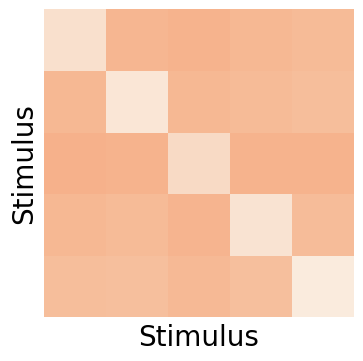

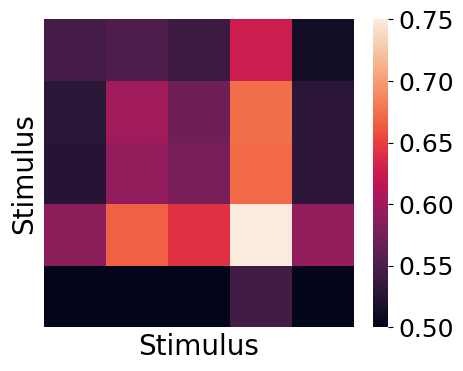

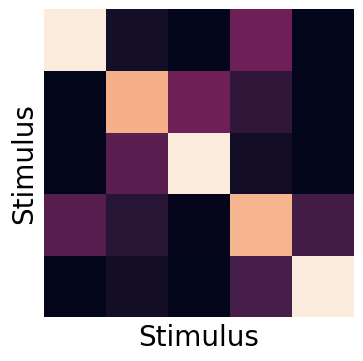

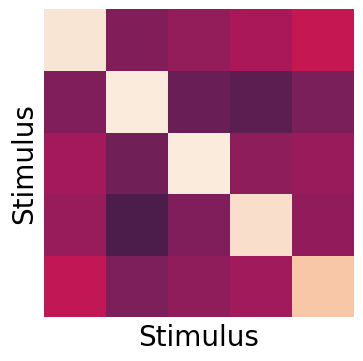

In [28]:
# RSM heatmap

similarity_type = 'cos_sim'

save_file_name = 'RSA_across_within_sess_all27.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_RSM_mean2 = RSA_across_within_sess_all['list_RSM_mean2'].copy()
n_sessions = list_RSM_mean2.shape[0]
list_Q = [5, 10, 20, 50, 100]
n_stims = 5; n_trials = 200; dur_stim = 250; stim_amp = 0.1

similarity_type = 'cos_sim'
save_file_name = 'RSA_across_within_sess_' + similarity_type + '_all4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, within sess RSM, Q=1
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_RSM_mean2_Q1 = RSA_across_within_sess_all['list_RSM_mean2'].copy()
list_Q1 = [1]
list_Q_all = list_Q1 + list_Q
list_RSM_mean2_all = np.concatenate([list_RSM_mean2_Q1, list_RSM_mean2], axis=1)

list_range = [(0.71, 0.73), (0.45, 0.75), (0.5, 0.7), (0.5, 0.75)]
for sess_ind in range(n_sessions):
    if sess_ind == 6:
        for ind, Q in enumerate(list_Q_all[:4]):
            # if Q == 20:
                # print(f'sess_ind = {sess_ind}, Q = {Q}, slope = {np.nanmean(list_slopes_Qstcl[sess_ind, ind]):.2f}')
                num_trial_types = n_stims

                if Q == 5:
                    cbar = True
                else:
                    cbar = False
                vmin, vmax = list_range[ind]
                vmin, vmax = 0.5, 0.75
                figsize = (4, 4)

                RSM_temp = list_RSM_mean2_all[sess_ind, ind, :num_trial_types, :num_trial_types]
                if cbar:
                    fig, ax_hm, ax_cb = heatmap_cbar(RSM_temp,
                                                    vmin=vmin, vmax=vmax,
                                                    # cbar_kws=cbar_kws,
                                                    )
                    ax_cb.tick_params(labelsize=18)
                else:
                    fig, ax_hm = plt.subplots(1, 1, figsize=figsize)
                    ax_hm = sns.heatmap(RSM_temp,
                                        vmin=vmin, vmax=vmax,
                                        cbar=cbar)
                
                ax_hm.set_xlabel('Stimulus', fontsize=20)
                ax_hm.set_ylabel('Stimulus', fontsize=20)
                ax_hm.set_xticks([])
                ax_hm.set_yticks([])

                # # plt.savefig(f'code_images\\SNN_RSM_across_Q{Q}_cbar{cbar}.svg', bbox_inches='tight')
                # # plt.savefig(f'code_images\\SNN_RSM_across_Q{Q}_cbar{cbar}.png', dpi=300, bbox_inches='tight')
                # plt.savefig(f'code_images\\svg\\SNN_RSM_across_Q{Q}.svg', bbox_inches='tight')
                # plt.savefig(f'code_images\\png\\SNN_RSM_across_Q{Q}.png', dpi=300, bbox_inches='tight')
                plt.show()

## Supplementary Figure 16d

1 vs. 75 p=0.0117
1 vs. 150 p=0.0117
1 vs. 300 p=0.0117
75 vs. 150 p=0.0117
75 vs. 300 p=0.0117
150 vs. 300 p=0.0840


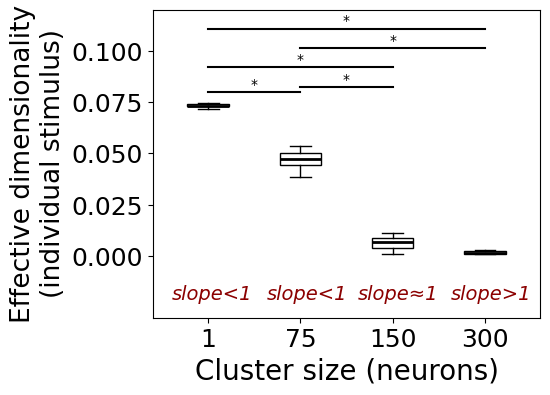

In [29]:
# Effective dimensionality (box plot)

save_file_name = 'eff_dim_DC_SNN3.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control (cf. save27), math corrected
with open(save_file_name, 'rb') as f:
    eff_dim_DC_SNN = pickle.load(f)
    list_spkcnt_Qstcl = eff_dim_DC_SNN['list_spkcnt_Qstcl'].copy()
    list_dim2 = eff_dim_DC_SNN['list_dim2'].copy()
    list_dim_global2 = eff_dim_DC_SNN['list_dim_global2'].copy()
    list_dim_sam2 = eff_dim_DC_SNN['list_dim_sam2'].copy()
save_file_name = 'eff_dim_DC_SNN4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, Q=1, math corrected
with open(save_file_name, 'rb') as f:
    eff_dim_DC_SNN = pickle.load(f)
    list_dim2_Q1 = eff_dim_DC_SNN['list_dim2'].copy()
    list_dim_global2_Q1 = eff_dim_DC_SNN['list_dim_global2'].copy()
    list_dim_sam2_Q1 = eff_dim_DC_SNN['list_dim_sam2'].copy()
list_dim2_all = np.concatenate([list_dim2_Q1, list_dim2], axis=1)
list_dim_global2_all = np.concatenate([list_dim_global2_Q1, list_dim_global2], axis=1)
list_dim_sam2_all = np.concatenate([list_dim_sam2_Q1, list_dim_sam2], axis=1)

n_sessions = list_spkcnt_Qstcl.shape[0]
list_seed = np.linspace(1, 901, n_sessions, endpoint=True).astype(int)
list_Q = [5, 10, 20, 50, 100]
list_Q1 = [1]
list_Q_all = list_Q1 + list_Q
n_stims = 5; n_trials = 200; dur_stim = 250; stim_amp = 0.1; stim_overlap = False; match_amp = True
N_E = 1200
list_en_size = [int(N/Q) for Q in list_Q]

# bar plot and scatterplot
list_dim2 = np.mean(list_dim2_all, axis=2)

# # global dimensionality
# glo_ind = 0
# list_dim2 = list_dim_global2_all[:, :, glo_ind]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
num_cond = 4

list_dim_intv = np.empty(num_cond, dtype=object)
list_means_dim = np.zeros(num_cond)
list_errs_dim = np.zeros(num_cond)
for intv_ind in range(num_cond):
    list_dim_intv[intv_ind] = list_dim2[:, 3-intv_ind] # Q = 20, 10, 5, 1

    list_means_dim[intv_ind] = np.mean(list_dim_intv[intv_ind])
    list_errs_dim[intv_ind] = sem(list_dim_intv[intv_ind])
list_dim_intv = list_dim_intv[[3, 0, 1, 2]]

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = [1, 75, 150, 300]
d_x = 0

box = axes[0].boxplot([list_dim_intv[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w', alpha=1) # box color
    median_.set(color='k', linewidth=2, alpha=1) # median line color

# significance
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_dim = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    # list_pvals_dim[pair_ind] = list(mannwhitneyu(list_dim_intv[pair[0]], list_dim_intv[pair[1]]))[1]
    list_pvals_dim[pair_ind] = list(wilcoxon(list_dim_intv[pair[0]], list_dim_intv[pair[1]]))[1]
list_pvals_dim = np.array(multipletests(list_pvals_dim, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_dim[pair_ind]:.4f}')

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_ylim(-0.03, 0.12) # individual
# axes[0].set_ylim(-0.03, 0.18) # global
whiskers = [get_upper_whisker(d) for d in list_dim_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*num_cond, x_positions=center,
                      p_values=list_pvals_dim, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlabel('Number of clusters', fontsize=20)
axes[0].set_xlabel('Neurons per cluster', fontsize=20)
axes[0].set_xlabel('Cluster size (neurons)', fontsize=20)
# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
# axes[0].set_ylabel('Effective dimensionality\n(all trials)', fontsize=19)
axes[0].tick_params('both', labelsize=18)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(np.arange(0, 0.11, 0.025)) # individual
# axes[0].set_yticks(np.arange(0, 0.121, 0.03)) # global

# axes[0].annotate('slope', xy=(0.05, 0.18), xycoords='axes fraction', fontsize=18, color='k')
list_texts = ['slope<1', 'slope<1', 'slope≈1', 'slope>1'] # fontsize=14
list_xcoords = [0.05, 0.295, 0.53, 0.77]
for text, xcoord in zip(list_texts, list_xcoords):
    axes[0].annotate(text, xy=(xcoord, 0.06), xycoords='axes fraction', fontsize=14, fontstyle='italic', color='darkred')
# axes[0].annotate(f'n = {list_dim2.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\SNN_effdim_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\SNN_effdim_interval.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\SNN_effdim_glo_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\SNN_effdim_glo_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 16e

In [30]:
# # Collect decoding for each session
# decoder_type = 'SVM'
# n_sessions = 10
# list_Q = [5, 10, 20, 50, 100]
# # list_Q = [1]
# n_stims = 5

# list_spkcnt_Qstcl = np.empty((n_sessions, len(list_Q)), dtype=object)
# list_slopes_Qstcl = np.full((n_sessions, len(list_Q), n_stims), np.nan)
# list_params_sim = np.empty((n_sessions, len(list_Q)), dtype=object)
# list_mean_confusion_test2 = np.full((n_sessions, len(list_Q), n_stims, n_stims), np.nan)
# list_mean_accuracy2 = np.full((n_sessions, len(list_Q)), np.nan)
# for sess_ind in range(n_sessions):
#     file_name = decoder_type + '_decoding_SNN_allstim_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         decoding_SNN_allstim = pickle.load(f)
#         list_spkcnt_Qstcl[sess_ind] = decoding_SNN_allstim['list_spkcnt_Qstcl'].copy()
#         list_slopes_Qstcl[sess_ind] = decoding_SNN_allstim['list_slopes_Qstcl'].copy()
#         list_params_sim[sess_ind] = decoding_SNN_allstim['list_params_sim'].copy()
#         list_mean_confusion_test2[sess_ind] = decoding_SNN_allstim['list_mean_confusion_test'].copy()
#         list_mean_accuracy2[sess_ind] = decoding_SNN_allstim['list_mean_accuracy'].copy()

# save_file_name = decoder_type + '_decoding_SNN_allstim_all4.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_spkcnt_Qstcl', 'list_slopes_Qstcl', 'list_params_sim', 'list_mean_confusion_test2', 'list_mean_accuracy2'],
#     'list_spkcnt_Qstcl': list_spkcnt_Qstcl, 'list_slopes_Qstcl': list_slopes_Qstcl, 'list_params_sim': list_params_sim,
#     'list_mean_confusion_test2': list_mean_confusion_test2, 'list_mean_accuracy2': list_mean_accuracy2}, f)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


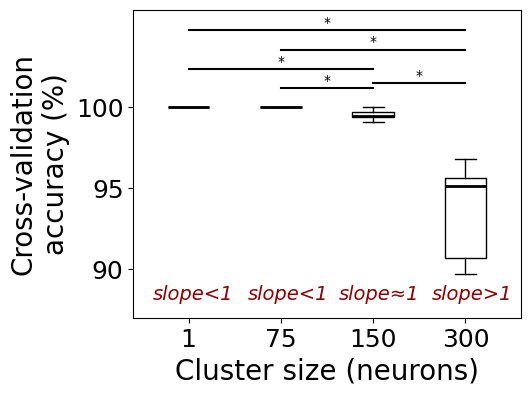

In [32]:
decoder_type = 'SVM'

save_file_name = decoder_type + '_decoding_SNN_allstim_all.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control (cf. save27)
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_slopes_Qstcl = RSA_across_within_sess_all['list_slopes_Qstcl'].copy()
    list_params_sim = RSA_across_within_sess_all['list_params_sim'].copy()
    # list_mean_confusion_test2 = RSA_across_within_sess_all['list_mean_confusion_test2'].copy()
    list_mean_accuracy2 = RSA_across_within_sess_all['list_mean_accuracy2'].copy()
n_sessions = list_mean_accuracy2.shape[0]
list_mean_accuracy2 = 100 * list_mean_accuracy2

save_file_name = decoder_type + '_decoding_SNN_allstim_all4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, Q=1
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_mean_accuracy2_Q1 = RSA_across_within_sess_all['list_mean_accuracy2'].copy()
list_mean_accuracy2_Q1 = 100 * list_mean_accuracy2_Q1
list_mean_accuracy2 = np.concatenate([list_mean_accuracy2_Q1, list_mean_accuracy2], axis=1)

list_Q = [5, 10, 20, 50, 100]
list_Q = [1, 5, 10, 20, 50, 100]
n_stims = 5; n_trials = 200; dur_stim = 250; stim_amp = 0.1

# bar plot and scatterplot
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
num_cond = 4

list_accuracy_intv = np.empty(num_cond, dtype=object)
list_means_accuracy = np.zeros(num_cond)
list_errs_accuracy = np.zeros(num_cond)
for intv_ind in range(num_cond):
    list_accuracy_intv[intv_ind] = list_mean_accuracy2[:, 3-intv_ind].copy() # Q = 20, 10, 5, 1

    list_means_accuracy[intv_ind] = np.mean(list_accuracy_intv[intv_ind])
    list_errs_accuracy[intv_ind] = sem(list_accuracy_intv[intv_ind])
list_accuracy_intv = list_accuracy_intv[[3, 0, 1, 2]]

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = [1, 75, 150, 300]
d_x = 0

box = axes[0].boxplot([list_accuracy_intv[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w', alpha=1) # box color
    median_.set(color='k', linewidth=2, alpha=1) # median line color

# significance
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_accuracy = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    try:
        # list_pvals_accuracy[pair_ind] = list(mannwhitneyu(list_accuracy_intv[pair[0]], list_accuracy_intv[pair[1]]))[1]
        list_pvals_accuracy[pair_ind] = list(wilcoxon(list_accuracy_intv[pair[0]], list_accuracy_intv[pair[1]]))[1]
    except:
        list_pvals_accuracy[pair_ind] = 1
list_pvals_accuracy = np.array(multipletests(list_pvals_accuracy, method='holm')[1]) # multiple comparisons correction

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_ylim(87, 105)
axes[0].set_ylim(87, 106)
# axes[0].set_ylim(-10, 70)
whiskers = [get_upper_whisker(d) for d in list_accuracy_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.008]*num_cond, x_positions=center,
                      p_values=list_pvals_accuracy, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlabel('Number of clusters', fontsize=20)
axes[0].set_xlabel('Neurons per cluster', fontsize=20)
axes[0].set_xlabel('Cluster size (neurons)', fontsize=20)
# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
axes[0].tick_params('both', labelsize=18)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(np.arange(90, 101, 5))
# axes[0].set_yticks(np.arange(0, 101, 25))

# axes[0].annotate('slope', xy=(0.05, 0.18), xycoords='axes fraction', fontsize=18, color='k')
list_texts = ['slope<1', 'slope<1', 'slope≈1', 'slope>1'] # fontsize=14
list_xcoords = [0.05, 0.295, 0.53, 0.77]
for text, xcoord in zip(list_texts, list_xcoords):
    axes[0].annotate(text, xy=(xcoord, 0.06), xycoords='axes fraction', fontsize=14, fontstyle='italic', color='darkred')
# axes[0].annotate(f'n = {list_mean_accuracy2.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\SNN_decoding_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\SNN_decoding_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 16f

[0.00195312 0.06445312 0.00195312 0.00195312 0.00195312]
1 vs. 75 p=0.0117
1 vs. 150 p=0.0117
1 vs. 300 p=0.0117
75 vs. 150 p=0.0117
75 vs. 300 p=0.0117
150 vs. 300 p=0.0645


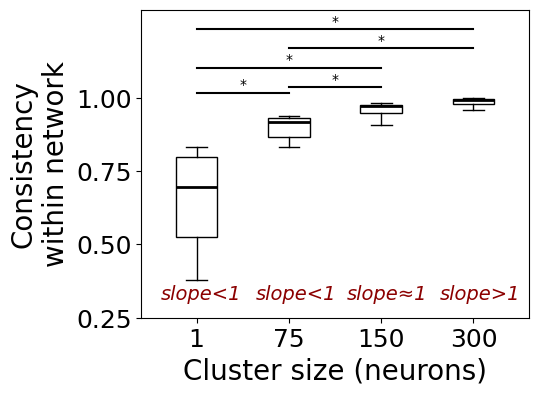

In [33]:
# RSA within sessions

similarity_type = 'cos_sim'

save_file_name = 'RSA_across_within_sess_all27.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_slopes_Qstcl = RSA_across_within_sess_all['list_slopes_Qstcl'].copy()
    list_params_sim = RSA_across_within_sess_all['list_params_sim'].copy()
    # list_RSM_mean2 = RSA_across_within_sess_all['list_RSM_mean2'].copy()
    list_corr_withinsess2 = RSA_across_within_sess_all['list_corr_withinsess2'].copy()
save_file_name = 'RSA_across_within_sess_' + similarity_type + '_all4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, within sess RSM, Q=1
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_corr_withinsess2_Q1 = RSA_across_within_sess_all['list_corr_withinsess2'].copy()
list_corr_withinsess2 = np.concatenate([list_corr_withinsess2_Q1, list_corr_withinsess2], axis=1)

list_Q = [5, 10, 20, 50, 100]
list_Q = [1, 5, 10, 20, 50, 100]

# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_withinsess = np.array([[list(wilcoxon(list_corr_withinsess2[:, 1, :, corr_ind].mean(axis=1), list_corr_withinsess2[:, ind, :, corr_ind].mean(axis=1), nan_policy='omit'))[1] \
                                               for ind in np.delete(range(len(list_Q)), 1)] for corr_ind in range(3)])

corr_ind = 0
# list_sig_slopes_corr_withinsess = list_Q[list_pvals_corr_withinsess[corr_ind] < 0.05].copy()
print(list_pvals_corr_withinsess[corr_ind])
n_sessions = list_slopes_Qstcl.shape[0]

# bar plot and scatterplot
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
num_cond = 4

list_corr_withinsess_intv = np.empty(num_cond, dtype=object)
list_means_corr_withinsess = np.zeros(num_cond)
list_errs_corr_withinsess = np.zeros(num_cond)
for intv_ind in range(num_cond):
    list_corr_withinsess_intv[intv_ind] = np.mean(list_corr_withinsess2[:, :, :, corr_ind], axis=2)[:, 3-intv_ind] # Q = 20, 10, 5, 1
    
    list_means_corr_withinsess[intv_ind] = np.mean(list_corr_withinsess_intv[intv_ind])
    list_errs_corr_withinsess[intv_ind] = sem(list_corr_withinsess_intv[intv_ind])
list_corr_withinsess_intv = list_corr_withinsess_intv[[3, 0, 1, 2]]

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = [1, 75, 150, 300]
d_x = 0

box = axes[0].boxplot([list_corr_withinsess_intv[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w', alpha=1) # box color
    median_.set(color='k', linewidth=2, alpha=1) # median line color

# significance
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_corr_withinsess = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    # list_pvals_corr_withinsess[pair_ind] = list(mannwhitneyu(list_corr_withinsess_intv[pair[0]], list_corr_withinsess_intv[pair[1]]))[1]
    list_pvals_corr_withinsess[pair_ind] = list(wilcoxon(list_corr_withinsess_intv[pair[0]], list_corr_withinsess_intv[pair[1]]))[1]
list_pvals_corr_withinsess = np.array(multipletests(list_pvals_corr_withinsess, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_corr_withinsess[pair_ind]:.4f}')

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
# axes[0].set_ylim(0.75, 1.1)
# axes[0].set_ylim(0.92, 1.02)
axes[0].set_ylim(0.25, 1.3)
# axes[0].set_ylim(-0.45, 1.55)
# axes[0].set_ylim(0.8, 1.05)
whiskers = [get_upper_whisker(d) for d in list_corr_withinsess_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)]*num_cond, x_positions=center,
                      p_values=list_pvals_corr_withinsess, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlabel('Number of clusters', fontsize=20)
axes[0].set_xlabel('Neurons per cluster', fontsize=20)
axes[0].set_xlabel('Cluster size (neurons)', fontsize=20)
# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
# axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity\nwithin network', fontsize=20)
axes[0].set_ylabel('Consistency\nwithin network', fontsize=20)
axes[0].tick_params('both', labelsize=18)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
# axes[0].set_yticks(np.arange(np.round(axes[0].get_ylim()[0], 1), 1.1, 0.25))
axes[0].set_yticks(np.arange(0.25, 1.1, 0.25))
# axes[0].set_yticks(np.arange(-0.25, 1.01, 0.25))

# axes[0].annotate('slope', xy=(0.05, 0.18), xycoords='axes fraction', fontsize=18, color='k')
list_texts = ['slope<1', 'slope<1', 'slope≈1', 'slope>1'] # fontsize=14
list_xcoords = [0.05, 0.295, 0.53, 0.77]
for text, xcoord in zip(list_texts, list_xcoords):
    axes[0].annotate(text, xy=(xcoord, 0.06), xycoords='axes fraction', fontsize=14, fontstyle='italic', color='darkred')
# axes[0].annotate(f'n = {list_corr_withinsess2.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\SNN_RSA_within_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\SNN_RSA_within_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 16g

[3.26048166e-09 5.33174955e-07 5.13864507e-11 2.89981017e-09
 2.06919708e-08]
1 vs. 75 p=0.0760
1 vs. 150 p=0.1873
1 vs. 300 p=0.0000
75 vs. 150 p=0.0199
75 vs. 300 p=0.0000
150 vs. 300 p=0.0000


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


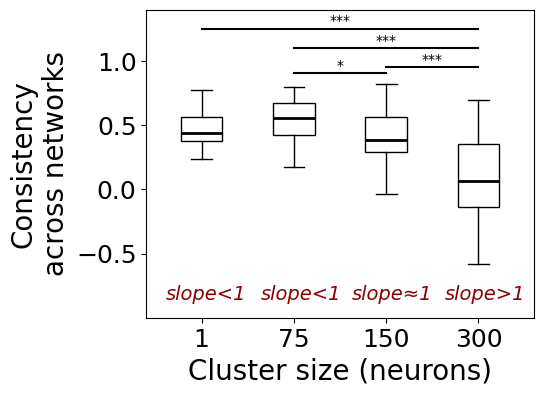

In [34]:
# RSA across session pairs

similarity_type = 'cos_sim'

save_file_name = 'RSA_across_within_sess_all27.pickle' # m4, stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_slopes_Qstcl = RSA_across_within_sess_all['list_slopes_Qstcl'].copy()
    list_params_sim = RSA_across_within_sess_all['list_params_sim'].copy()
    list_RSM_mean2 = RSA_across_within_sess_all['list_RSM_mean2'].copy()
save_file_name = 'RSA_across_within_sess_' + similarity_type + '_all4.pickle' # stim_amp 0.1, 10 sessions (seed 1-901), trial/neuron division matching, V_m/conn control, stim_neu, within sess RSM, Q=1
with open(save_file_name, 'rb') as f:
    RSA_across_within_sess_all = pickle.load(f)
    list_RSM_mean2_Q1 = RSA_across_within_sess_all['list_RSM_mean2'].copy()
list_RSM_mean2 = np.concatenate([list_RSM_mean2_Q1, list_RSM_mean2], axis=1)

n_sessions = list_RSM_mean2.shape[0]
list_Q = [5, 10, 20, 50, 100]
list_Q = [1, 5, 10, 20, 50, 100]

# Spearman correlation across session pairs
num_trial_types = 5
sess_pairs = list(combinations(range(n_sessions), 2))
list_corr_sesspair2 = np.zeros((len(sess_pairs), len(list_Q), 3))
for pair_ind, pair in enumerate(sess_pairs):
    for ind, Q in enumerate(list_Q):
        RSM_mean_neu1 = list_RSM_mean2[pair[0], ind].copy()
        RSM_mean_neu2 = list_RSM_mean2[pair[1], ind].copy()

        # # exclude diagonal
        # RSM_mean_neu1[np.diag_indices(num_trial_types)] = np.nan
        # RSM_mean_neu2[np.diag_indices(num_trial_types)] = np.nan
        
        list_corr_sesspair2[pair_ind, ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
        bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
        list_corr_sesspair2[pair_ind, ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
        list_corr_sesspair2[pair_ind, ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())
        
# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_sesspair = np.array([[list(wilcoxon(list_corr_sesspair2[:, 1, corr_ind], list_corr_sesspair2[:, ind, corr_ind], nan_policy='omit'))[1] \
                                               for ind in np.delete(range(len(list_Q)), 1)] for corr_ind in range(3)])

corr_ind = 0
# list_sig_slopes_corr_sesspair = list_Q[list_pvals_corr_sesspair[corr_ind] < 0.05].copy()
print(list_pvals_corr_sesspair[corr_ind])

# bar plot and scatterplot
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
num_cond = 4

list_corr_sesspair_intv = np.empty(num_cond, dtype=object)
list_means_corr_sesspair = np.zeros(num_cond)
list_errs_corr_sesspair = np.zeros(num_cond)
for intv_ind in range(num_cond):
    list_corr_sesspair_intv[intv_ind] = list_corr_sesspair2[:, 3-intv_ind, corr_ind].copy() # Q = 20, 10, 5, 1
    
    list_means_corr_sesspair[intv_ind] = np.mean(list_corr_sesspair_intv[intv_ind])
    list_errs_corr_sesspair[intv_ind] = sem(list_corr_sesspair_intv[intv_ind])
list_corr_sesspair_intv = list_corr_sesspair_intv[[3, 0, 1, 2]]

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = [1, 75, 150, 300]
d_x = 0

box = axes[0].boxplot([list_corr_sesspair_intv[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w', alpha=1) # box color
    median_.set(color='k', linewidth=2, alpha=1) # median line color

# significance
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_corr_sesspair = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    # list_pvals_corr_sesspair[pair_ind] = list(mannwhitneyu(list_corr_sesspair_intv[pair[0]], list_corr_sesspair_intv[pair[1]]))[1]
    list_pvals_corr_sesspair[pair_ind] = list(wilcoxon(list_corr_sesspair_intv[pair[0]], list_corr_sesspair_intv[pair[1]]))[1]
list_pvals_corr_sesspair = np.array(multipletests(list_pvals_corr_sesspair, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_corr_sesspair[pair_ind]:.4f}')
    
axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_ylim(-1, 1.4)
# axes[0].set_ylim(-1, 0.8)
whiskers = [get_upper_whisker(d) for d in list_corr_sesspair_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.05]*num_cond, x_positions=center,
                      p_values=list_pvals_corr_sesspair, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlabel('Number of clusters', fontsize=20)
axes[0].set_xlabel('Neurons per cluster', fontsize=20)
axes[0].set_xlabel('Cluster size (neurons)', fontsize=20)
# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
# axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity\nacross networks', fontsize=20)
axes[0].set_ylabel('Consistency\nacross networks', fontsize=20)
axes[0].tick_params('both', labelsize=18)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
# axes[0].set_yticks(np.arange(np.round(axes[0].get_ylim()[0], 1), 1.1, 0.5))
axes[0].set_yticks(np.arange(-0.5, 1.1, 0.5))

# axes[0].annotate('slope', xy=(0.05, 0.18), xycoords='axes fraction', fontsize=18, color='k')
list_texts = ['slope<1', 'slope<1', 'slope≈1', 'slope>1'] # fontsize=14
list_xcoords = [0.05, 0.295, 0.53, 0.77]
for text, xcoord in zip(list_texts, list_xcoords):
    axes[0].annotate(text, xy=(xcoord, 0.06), xycoords='axes fraction', fontsize=14, fontstyle='italic', color='darkred')
# axes[0].annotate(f'n = {list_corr_sesspair2.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\SNN_RSA_across_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\SNN_RSA_across_interval.png', dpi=300, bbox_inches='tight')
plt.show()